# Belauri Indoor vs Outdoor Air Quality — Comparative Analysis

| | Sensor |
|---|---|
| **Outdoor** | Bluesky `81432434001` (Model 8143) |
| **Indoor** | Air Assure `81442406076` (Model 8144) |
| **Location** | Belauri, Nepal — 28.6844°N, 80.3646°E |
| **Overlap period** | 24 Nov 2025 – 1 Apr 2026 (128 days, Nepal winter–pre-monsoon haze season) |

**Hypothesis:** Indoor PM2.5 concentrations are higher than outdoor at this site.  
**Additional channels unique to indoor sensor:** CO2 (ppm), total VOC (mg/m³).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Colour palette — consistent throughout
C_OUT = '#2166AC'   # blue  — outdoor
C_IN  = '#D6604D'   # red   — indoor
C_WHO = '#1A9641'   # green — WHO guideline

DATA_ROOT = Path('/Users/yubraj/Code/air-quality-research/Data/Belauri')

LAT, LON = 28.6844194, 80.3645652
WHO_PM25_24H = 15   # µg/m³ WHO 2021 annual mean guideline
WHO_PM25_ANN = 5    # µg/m³ WHO 2021 24-h guideline
PM25_OUTLIER_CAP = 500  # µg/m³ — flag readings above this as suspect

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & Cleaning

In [2]:
# Columns to keep and rename
KEEP = {
    'Timestamp': 'ts',
    'Serial Number': 'serial',
    'Friendly Name': 'name',
    'Is Indoor': 'indoor',
    'PM2.5 AQI': 'pm25_aqi',
    'PM10 AQI': 'pm10_aqi',
    'PM1.0': 'pm1',
    'PM2.5': 'pm25',
    'PM4.0': 'pm4',
    'PM10': 'pm10',
    'PM0.5 NC': 'nc05',
    'PM1.0 NC': 'nc1',
    'PM2.5 NC': 'nc25',
    'Typical Particle Size': 'tps',
    'CO2': 'co2',
    'VOC tVOC measurement': 'tvoc',
    'Temperature': 'temp_c',
    'Relative Humidity': 'rh',
    'Barometric Pressure': 'baro_inhg',
    'PM Sensor Status': 'pm_status',
    'System Status': 'sys_status',
}


def load_sensor(paths: list) -> pd.DataFrame:
    parts = []
    for p in paths:
        df = pd.read_csv(p, skiprows=[1], low_memory=False)
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='mixed', utc=True)
        df = df.rename(columns={c: KEEP[c] for c in df.columns if c in KEEP})
        cols = [v for v in KEEP.values() if v in df.columns]
        parts.append(df[cols])
    out = pd.concat(parts, ignore_index=True).drop_duplicates(subset=['ts'])
    out = out.sort_values('ts').reset_index(drop=True)
    # Convert numeric columns
    num_cols = [c for c in out.columns if c not in ('ts','serial','name','indoor','pm_status','sys_status')]
    out[num_cols] = out[num_cols].apply(pd.to_numeric, errors='coerce')
    return out


OUT_FILES = sorted(DATA_ROOT.glob('81432434001-20*.csv'))
IN_FILES  = sorted((DATA_ROOT / '81442326017-81442406076-81442410021').glob('81442406076-20*.csv'))

out_raw = load_sensor(OUT_FILES)
in_raw  = load_sensor(IN_FILES)

out_raw['location'] = 'Outdoor'
in_raw['location']  = 'Indoor'

# --- Outlier flagging ---
# Mark extreme PM2.5 as suspect (sensor malfunction / contamination events)
for df in [out_raw, in_raw]:
    df['pm25_suspect'] = df['pm25'] > PM25_OUTLIER_CAP
    df['pm25_clean']   = df['pm25'].where(df['pm25'] <= PM25_OUTLIER_CAP)
    df['pm10_clean']   = df['pm10'].where(df['pm10'] <= PM25_OUTLIER_CAP * 2)

n_out_flag = out_raw['pm25_suspect'].sum()
n_in_flag  = in_raw['pm25_suspect'].sum()
print(f'Outdoor: {len(out_raw):,} rows | {n_out_flag:,} PM2.5 readings flagged (>{PM25_OUTLIER_CAP} µg/m³)')
print(f'Indoor:  {len(in_raw):,} rows  | {n_in_flag:,} PM2.5 readings flagged')

# --- Overlap period ---
OV_START = in_raw['ts'].min()
OV_END   = in_raw['ts'].max()

out_ov = out_raw[(out_raw['ts'] >= OV_START) & (out_raw['ts'] <= OV_END)].copy()
in_ov  = in_raw.copy()

print(f'\nOverlap: {OV_START.date()} → {OV_END.date()} ({(OV_END - OV_START).days} days)')
print(f'  Outdoor rows in overlap: {len(out_ov):,}')
print(f'  Indoor  rows in overlap: {len(in_ov):,}')

Outdoor: 291,588 rows | 1,394 PM2.5 readings flagged (>500 µg/m³)
Indoor:  167,188 rows  | 6,358 PM2.5 readings flagged

Overlap: 2025-11-24 → 2026-04-01 (128 days)
  Outdoor rows in overlap: 165,512
  Indoor  rows in overlap: 167,188


## 2. Descriptive Statistics

In [3]:
stat_channels = ['pm1','pm25_clean','pm10_clean','tps','co2','tvoc','temp_c','rh']

rows = []
for label, df in [('Outdoor (overlap)', out_ov), ('Indoor (overlap)', in_ov),
                   ('Outdoor (full record)', out_raw)]:
    for ch in stat_channels:
        if ch not in df.columns:
            continue
        s = df[ch].dropna()
        if len(s) == 0:
            continue
        rows.append({
            'Dataset': label, 'Channel': ch,
            'N': len(s),
            'Mean': round(s.mean(), 2),
            'Median': round(s.median(), 2),
            'Std': round(s.std(), 2),
            'P5': round(s.quantile(0.05), 2),
            'P95': round(s.quantile(0.95), 2),
            'Max': round(s.max(), 2),
        })

stats_df = pd.DataFrame(rows)
display(stats_df.set_index(['Dataset','Channel']))

N    Mean  Median     Std      P5  \
Dataset               Channel                                              
Outdoor (overlap)     pm1         165512  100.58   84.00   98.02   18.00   
                      pm25_clean  164129  102.16   89.00   70.20   19.00   
                      pm10_clean  165303  107.71   92.00   84.45   19.00   
                      tps         165512    0.55    0.54    0.04    0.50   
                      temp_c      165512   20.97   20.10    6.12   12.30   
                      rh          165512   62.81   66.00   11.89   37.00   
Indoor (overlap)      pm1         167188  134.86   98.00  157.09   23.00   
                      pm25_clean  160830  120.15  102.00   84.33   24.00   
                      pm10_clean  165920  139.32  105.00  131.26   24.00   
                      tps         167188    0.49    0.48    0.05    0.43   
                      co2         167188  534.37  522.00   96.21  408.00   
                      tvoc        167188    0.81    0.85    0.53    0.03   
                      temp_c      167188   19.91   19.00    4.27   14.10   
                      rh          167188   70.36   71.00    7.94   57.00   
Outdoor (full record) pm1         291588   58.49   34.00   88.41    0.00   
                      pm25_clean  290194   59.23   35.00   72.11    0.00   
                      pm10_clean  291375   62.58   36.00   82.13    0.00   
                      tps         291588    0.51    0.52    0.06    0.43   
                      temp_c      291588   22.87   23.30    5.53   13.60   
                      rh          291588   56.09   59.00   15.49   33.00   

                                     P95      Max  
Dataset               Channel                      
Outdoor (overlap)     pm1         233.00  5988.00  
                      pm25_clean  232.00   500.00  
                      pm10_clean  248.00   997.00  
                      tps           0.64     0.99  
                      temp_c       32.40    37.50  
                      rh           77.00    83.00  
Indoor (overlap)      pm1         395.00  5477.00  
                      pm25_clean  303.00   500.00  
                      pm10_clean  409.00  1000.00  
                      tps           0.58     0.87  
                      co2         706.00  1452.00  
                      tvoc          1.65     6.73  
                      temp_c       27.30    30.90  
                      rh           81.00    87.00  
Outdoor (full record) pm1         182.00  5988.00  
                      pm25_clean  188.00   500.00  
                      pm10_clean  196.00   997.00  
                      tps           0.62     0.99  
                      temp_c       32.30    37.50  
                      rh           77.00    86.00

## 3. Full PM2.5 Time Series (Outdoor)

Outdoor record spans Jul 2025 – Apr 2026. The winter–pre-monsoon haze season (Nov–Mar) is clearly elevated.

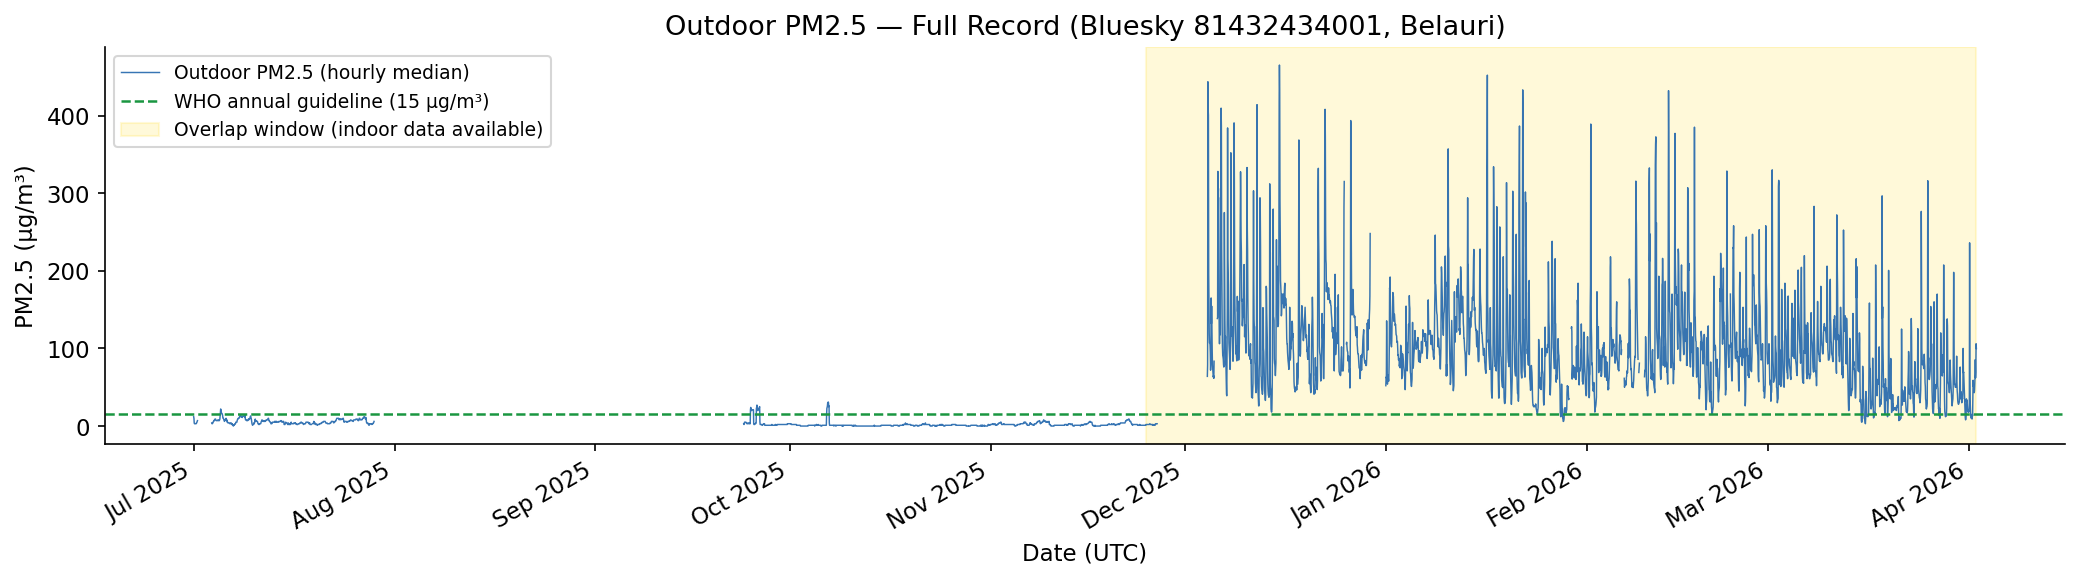

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))

# Hourly median
pm_out_hourly = out_raw.set_index('ts')['pm25_clean'].resample('1h').median()

ax.plot(pm_out_hourly.index, pm_out_hourly.values, lw=0.7, color=C_OUT, alpha=0.9, label='Outdoor PM2.5 (hourly median)')
ax.axhline(WHO_PM25_24H, color=C_WHO, lw=1.2, ls='--', label=f'WHO annual guideline ({WHO_PM25_24H} µg/m³)')

# Shade the overlap window
ax.axvspan(OV_START, OV_END, color='gold', alpha=0.15, label='Overlap window (indoor data available)')

ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_xlabel('Date (UTC)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title('Outdoor PM2.5 — Full Record (Bluesky 81432434001, Belauri)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Side-by-Side PM2.5 Time Series — Overlap Period

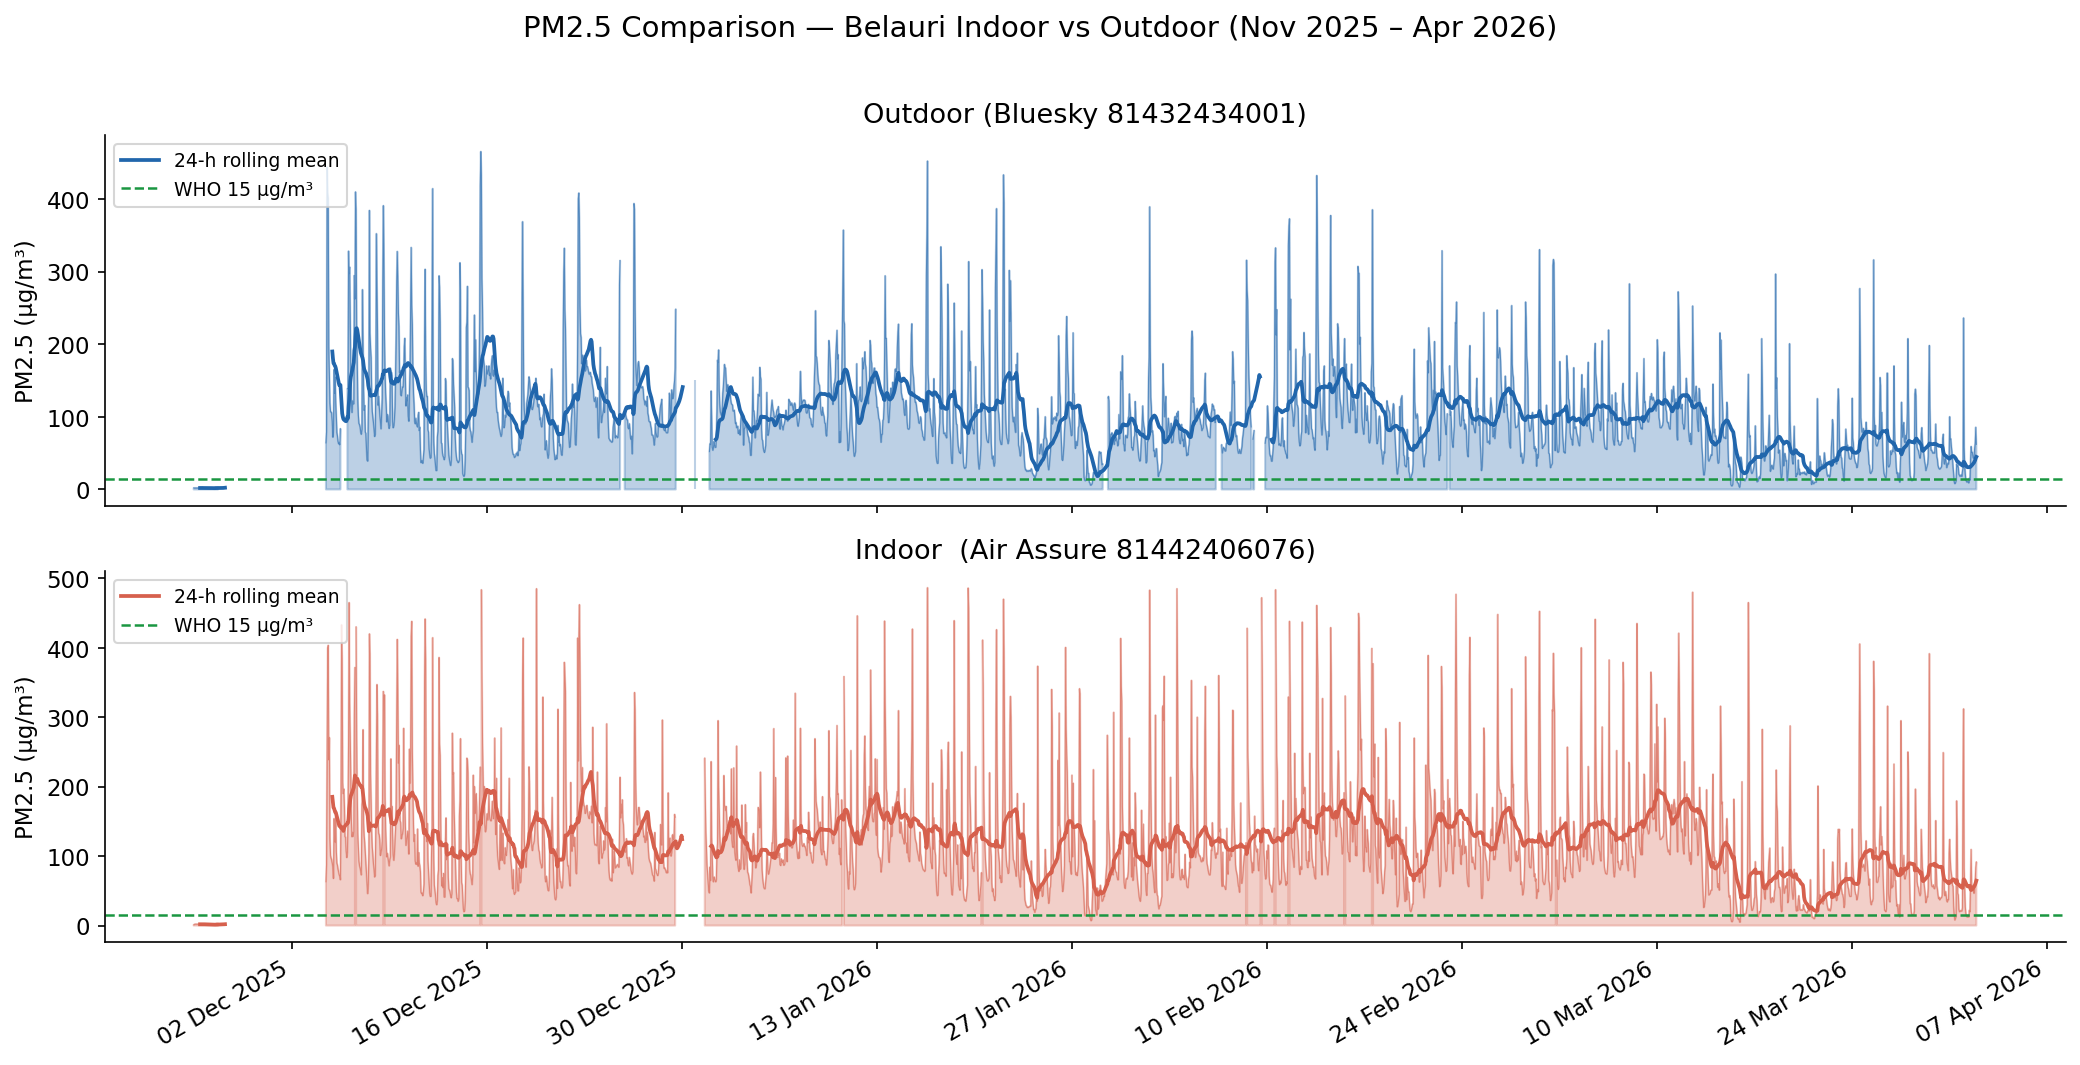

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

pm_out = out_ov.set_index('ts')['pm25_clean'].resample('1h').median()
pm_in  = in_ov.set_index('ts')['pm25_clean'].resample('1h').median()

for ax, pm, label, color in [
    (axes[0], pm_out, 'Outdoor (Bluesky 81432434001)', C_OUT),
    (axes[1], pm_in,  'Indoor  (Air Assure 81442406076)', C_IN),
]:
    # 24-h rolling mean
    roll = pm.rolling('24h', min_periods=12).mean()
    ax.fill_between(pm.index, pm.values, alpha=0.3, color=color)
    ax.plot(pm.index, pm.values, lw=0.5, color=color, alpha=0.6)
    ax.plot(roll.index, roll.values, lw=1.8, color=color, label='24-h rolling mean')
    ax.axhline(WHO_PM25_24H, color=C_WHO, lw=1.2, ls='--', label=f'WHO {WHO_PM25_24H} µg/m³')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(label)
    ax.legend(fontsize=9, loc='upper left')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')
fig.suptitle('PM2.5 Comparison — Belauri Indoor vs Outdoor (Nov 2025 – Apr 2026)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Overlaid Comparison with I/O Ratio

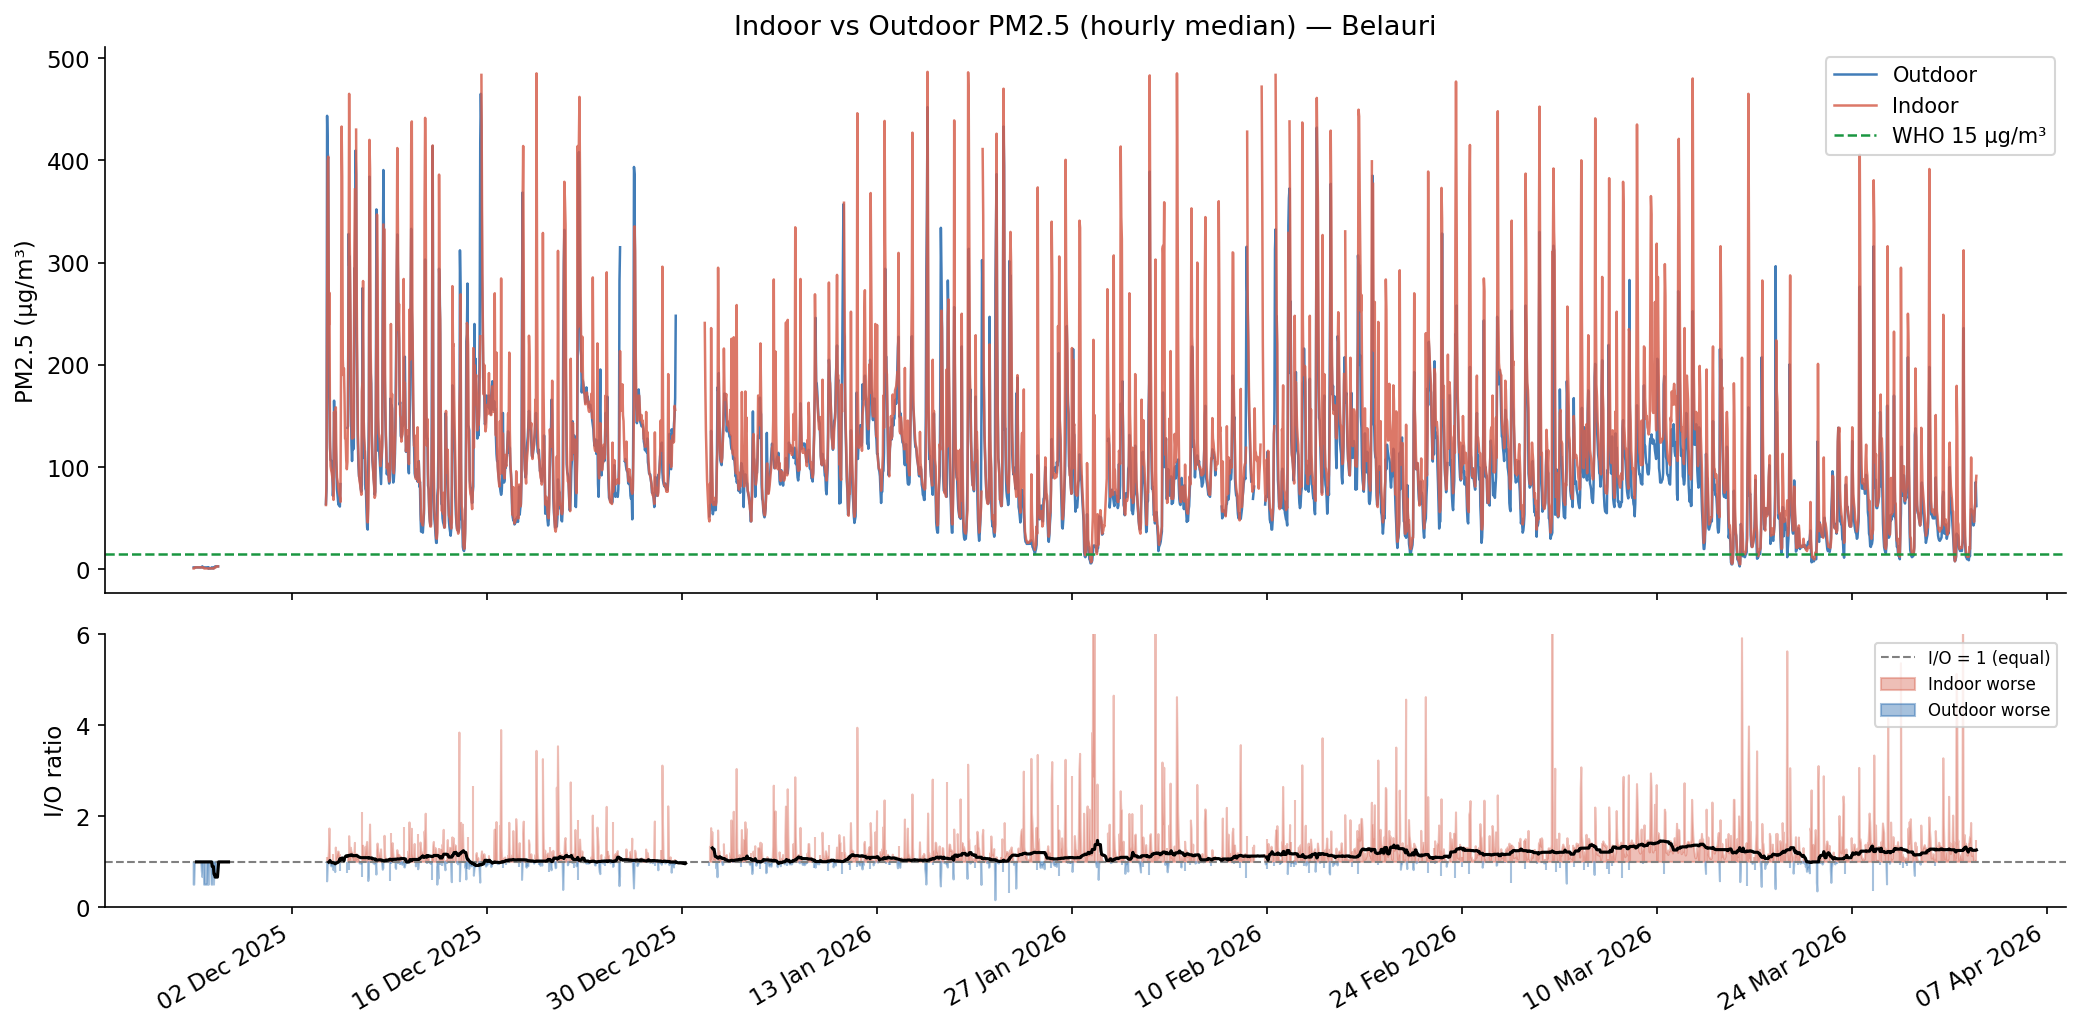

I/O ratio stats (hourly):
  Median I/O = 1.13
  Mean   I/O = 1.25
  % hours indoor > outdoor: 67.2%


In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.5]})

pm_out = out_ov.set_index('ts')['pm25_clean'].resample('1h').median()
pm_in  = in_ov.set_index('ts')['pm25_clean'].resample('1h').median()

ax1.plot(pm_out.index, pm_out.values, lw=1.2, color=C_OUT, label='Outdoor', alpha=0.85)
ax1.plot(pm_in.index,  pm_in.values,  lw=1.2, color=C_IN,  label='Indoor',  alpha=0.85)
ax1.axhline(WHO_PM25_24H, color=C_WHO, lw=1.2, ls='--', label=f'WHO {WHO_PM25_24H} µg/m³')
ax1.set_ylabel('PM2.5 (µg/m³)')
ax1.legend(fontsize=10)
ax1.set_title('Indoor vs Outdoor PM2.5 (hourly median) — Belauri')

# Indoor / Outdoor ratio (I/O)
# Align on common hourly index
common = pm_in.index.intersection(pm_out.index)
io_ratio = pm_in.loc[common] / pm_out.loc[common]
io_ratio = io_ratio.replace([np.inf, -np.inf], np.nan)

ax2.axhline(1.0, color='gray', lw=1, ls='--', label='I/O = 1 (equal)')
ax2.fill_between(io_ratio.index, io_ratio.values, 1,
                  where=io_ratio.values > 1, alpha=0.4, color=C_IN,  label='Indoor worse')
ax2.fill_between(io_ratio.index, io_ratio.values, 1,
                  where=io_ratio.values <= 1, alpha=0.4, color=C_OUT, label='Outdoor worse')
ax2.plot(io_ratio.index, io_ratio.rolling('24h', min_periods=6).median(), lw=1.5, color='black')
ax2.set_ylabel('I/O ratio')
ax2.set_ylim(0, 6)
ax2.legend(fontsize=8, loc='upper right')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(f'I/O ratio stats (hourly):')
print(f'  Median I/O = {io_ratio.median():.2f}')
print(f'  Mean   I/O = {io_ratio.mean():.2f}')
print(f'  % hours indoor > outdoor: {(io_ratio > 1).mean()*100:.1f}%')

## 6. Hypothesis Test — Is Indoor PM2.5 Significantly Higher?

We use hourly-averaged values aligned to the same timestamps.  
PM2.5 is not normally distributed → **Wilcoxon signed-rank test** (paired) on matched hours.

In [7]:
# Build matched hourly dataset
pm_out_h = out_ov.set_index('ts')['pm25_clean'].resample('1h').median().rename('pm25_out')
pm_in_h  = in_ov.set_index('ts')['pm25_clean'].resample('1h').median().rename('pm25_in')

matched = pd.concat([pm_out_h, pm_in_h], axis=1).dropna()
print(f'Matched hourly pairs: {len(matched):,}')

# Wilcoxon signed-rank test (H1: indoor > outdoor)
stat, pval = stats.wilcoxon(matched['pm25_in'], matched['pm25_out'], alternative='greater')

# Effect size: matched pairs mean difference
diff = matched['pm25_in'] - matched['pm25_out']
mean_diff = diff.mean()
median_diff = diff.median()

# Rank-biserial correlation as effect size
n = len(matched)
r_effect = 1 - (2 * stat) / (n * (n + 1) / 2)

print(f'\n--- Wilcoxon Signed-Rank Test (one-tailed: indoor > outdoor) ---')
print(f'  W statistic : {stat:.0f}')
print(f'  p-value     : {pval:.2e}')
print(f'  Conclusion  : {"Reject H0 — Indoor PM2.5 is significantly HIGHER" if pval < 0.05 else "Fail to reject H0"} (α=0.05)')
print(f'\n--- Effect Size ---')
print(f'  Mean  difference (IN − OUT): +{mean_diff:.1f} µg/m³')
print(f'  Median difference (IN − OUT): +{median_diff:.1f} µg/m³')
print(f'  Rank-biserial r: {r_effect:.3f}  (|r| > 0.5 = large effect)')

# Mann-Whitney U as cross-check (independent samples, all data)
mw_stat, mw_p = stats.mannwhitneyu(
    in_ov['pm25_clean'].dropna(),
    out_ov['pm25_clean'].dropna(),
    alternative='greater'
)
print(f'\n--- Mann-Whitney U (cross-check, all 1-min observations) ---')
print(f'  U statistic: {mw_stat:.0f}, p = {mw_p:.2e}')

Matched hourly pairs: 2,761

--- Wilcoxon Signed-Rank Test (one-tailed: indoor > outdoor) ---
  W statistic : 2967684
  p-value     : 2.84e-199
  Conclusion  : Reject H0 — Indoor PM2.5 is significantly HIGHER (α=0.05)

--- Effect Size ---
  Mean  difference (IN − OUT): +20.7 µg/m³
  Median difference (IN − OUT): +8.5 µg/m³
  Rank-biserial r: -0.557  (|r| > 0.5 = large effect)

--- Mann-Whitney U (cross-check, all 1-min observations) ---
  U statistic: 14914160578, p = 0.00e+00


## 7. Distribution Comparison — Box, Violin, and ECDF

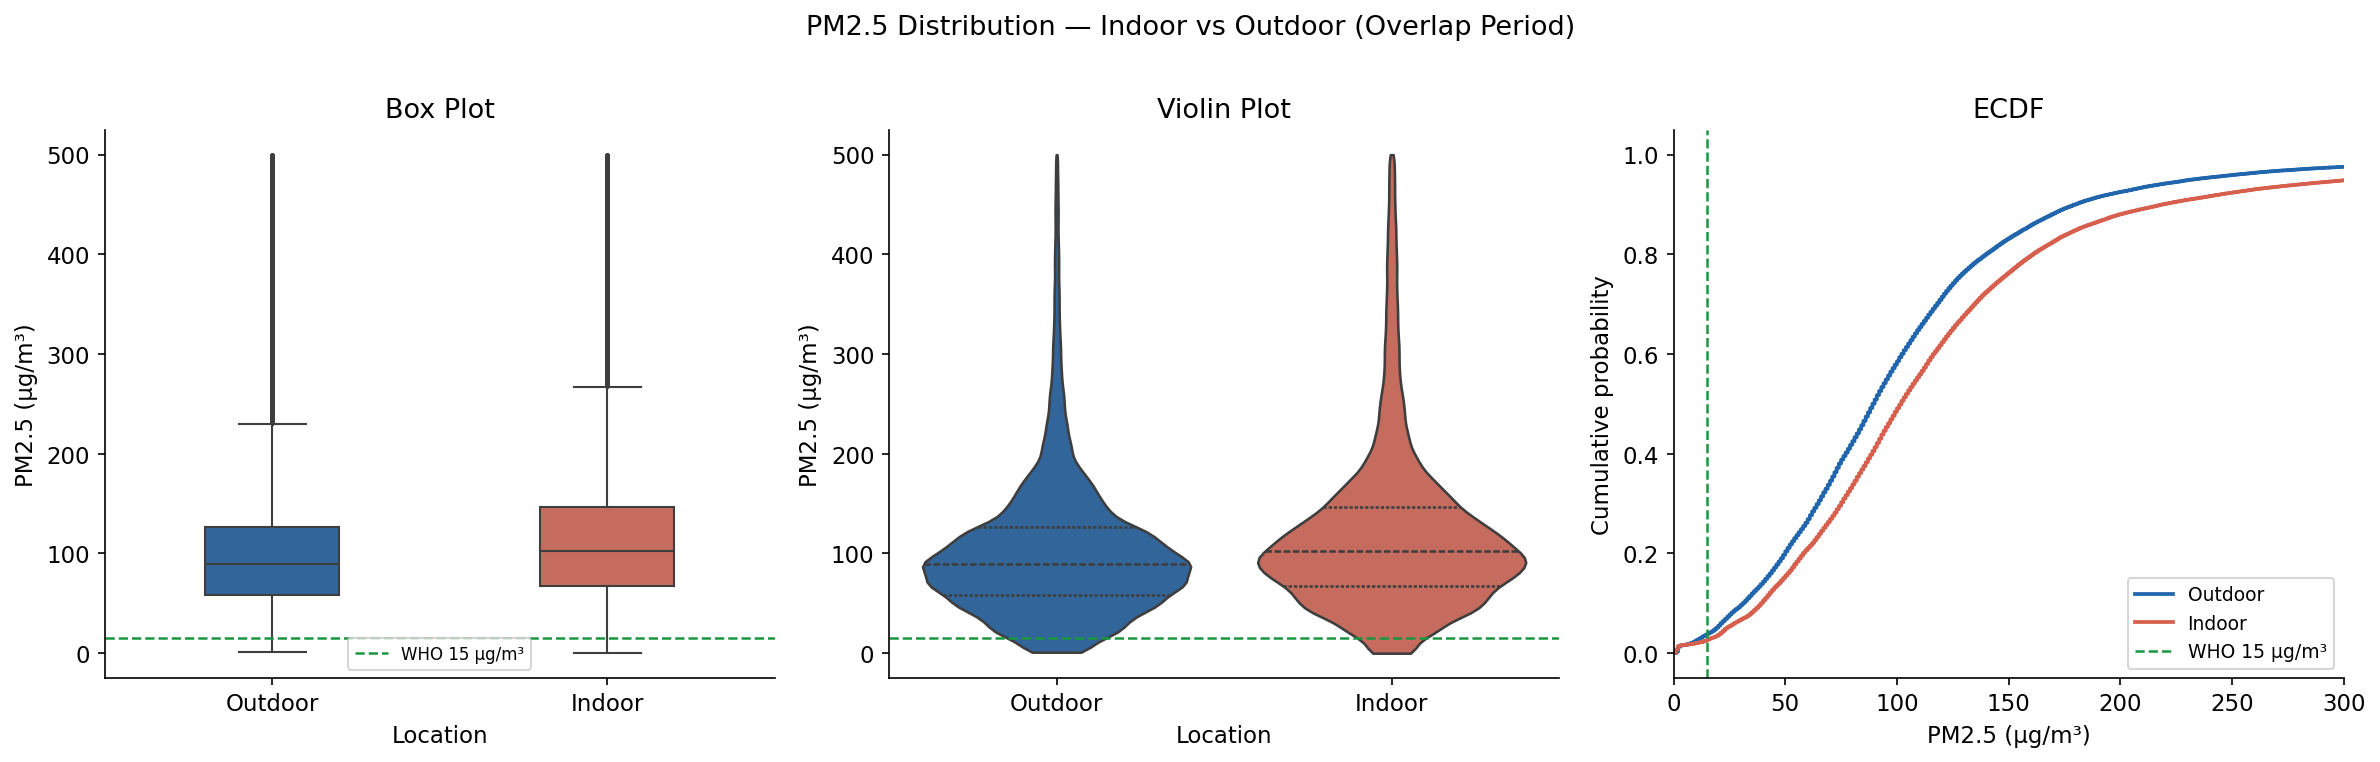

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_data = pd.concat([
    out_ov[['pm25_clean']].assign(Location='Outdoor'),
    in_ov[['pm25_clean']].assign(Location='Indoor'),
]).dropna(subset=['pm25_clean'])

palette = {'Outdoor': C_OUT, 'Indoor': C_IN}

# Box plot
sns.boxplot(data=plot_data, x='Location', y='pm25_clean', palette=palette,
            width=0.4, fliersize=1, ax=axes[0])
axes[0].axhline(WHO_PM25_24H, color=C_WHO, lw=1.2, ls='--', label=f'WHO {WHO_PM25_24H} µg/m³')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_title('Box Plot')
axes[0].legend(fontsize=8)

# Violin plot
sns.violinplot(data=plot_data, x='Location', y='pm25_clean', palette=palette,
               inner='quartile', cut=0, ax=axes[1])
axes[1].axhline(WHO_PM25_24H, color=C_WHO, lw=1.2, ls='--')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].set_title('Violin Plot')

# ECDF
for label, color in [('Outdoor', C_OUT), ('Indoor', C_IN)]:
    vals = plot_data[plot_data['Location'] == label]['pm25_clean'].dropna().sort_values()
    cdf  = np.arange(1, len(vals)+1) / len(vals)
    axes[2].plot(vals.values, cdf, lw=1.8, color=color, label=label)
axes[2].axvline(WHO_PM25_24H, color=C_WHO, lw=1.2, ls='--', label=f'WHO {WHO_PM25_24H} µg/m³')
axes[2].set_xlabel('PM2.5 (µg/m³)')
axes[2].set_ylabel('Cumulative probability')
axes[2].set_xlim(0, 300)
axes[2].set_title('ECDF')
axes[2].legend(fontsize=9)

fig.suptitle('PM2.5 Distribution — Indoor vs Outdoor (Overlap Period)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. AQI Category Breakdown

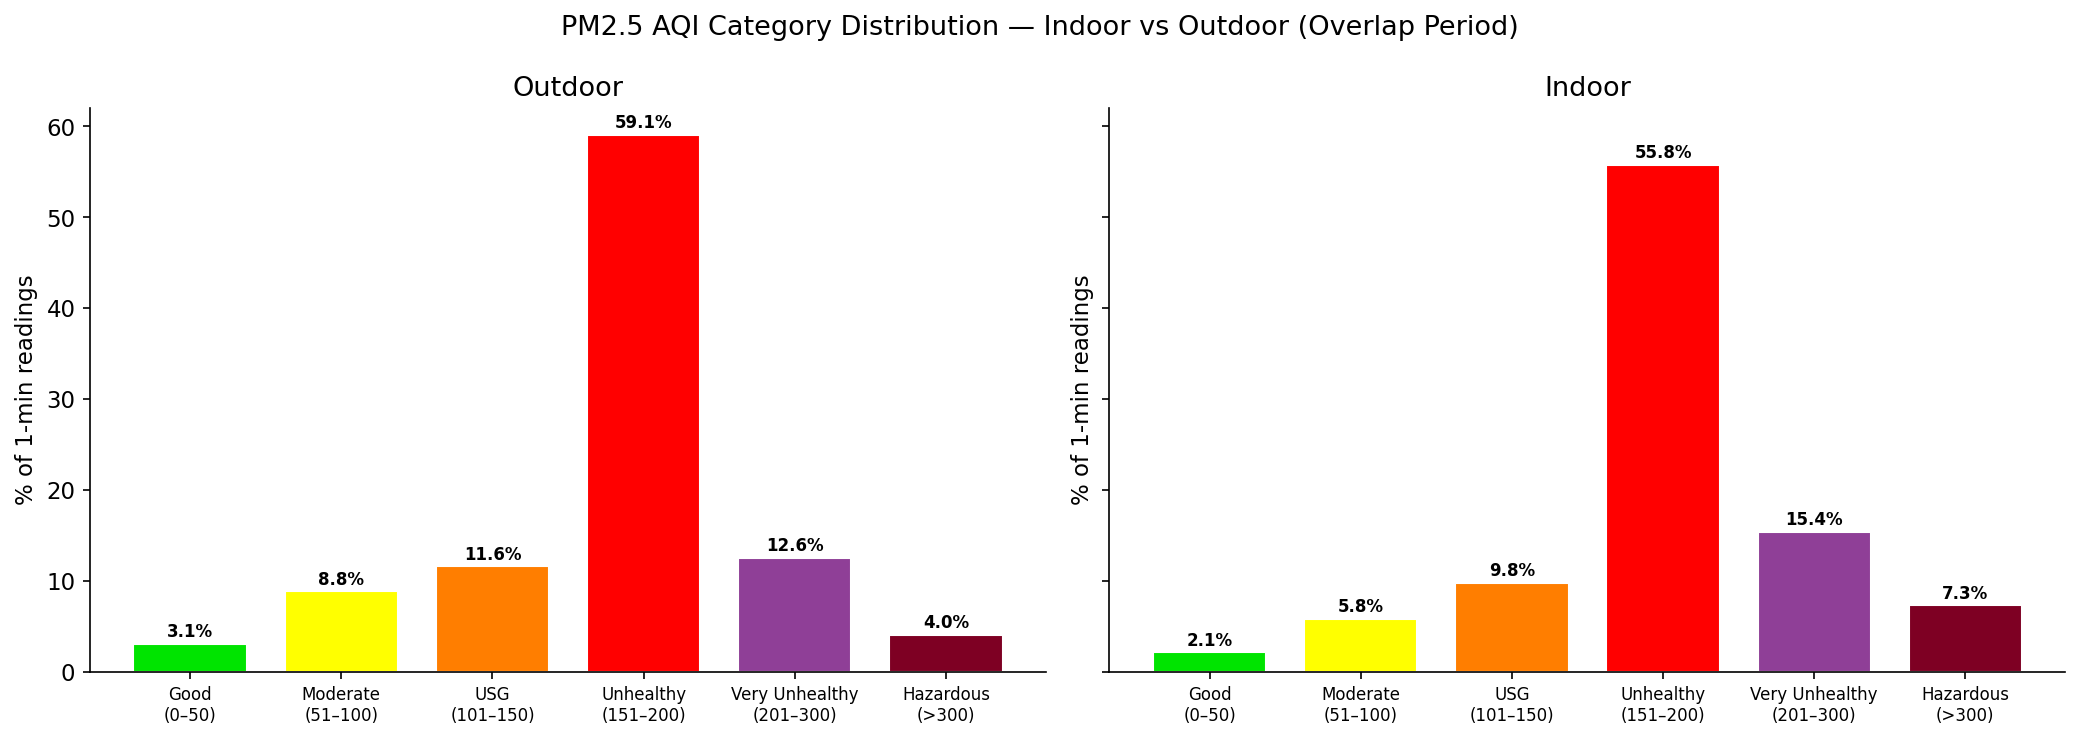

In [9]:
AQI_BREAKS  = [0, 50, 100, 150, 200, 300, 500]
AQI_LABELS  = ['Good\n(0–50)', 'Moderate\n(51–100)', 'USG\n(101–150)',
                'Unhealthy\n(151–200)', 'Very Unhealthy\n(201–300)', 'Hazardous\n(>300)']
AQI_COLORS  = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (label, df) in zip(axes, [('Outdoor', out_ov), ('Indoor', in_ov)]):
    aqi = df['pm25_aqi'].dropna()
    cats = pd.cut(aqi, bins=AQI_BREAKS, labels=AQI_LABELS, right=True)
    pct  = cats.value_counts().reindex(AQI_LABELS).fillna(0) / len(aqi) * 100

    bars = ax.bar(range(len(AQI_LABELS)), pct.values, color=AQI_COLORS, edgecolor='white', width=0.75)
    ax.set_xticks(range(len(AQI_LABELS)))
    ax.set_xticklabels(AQI_LABELS, fontsize=8)
    ax.set_ylabel('% of 1-min readings')
    ax.set_title(f'{label}')
    for bar, val in zip(bars, pct.values):
        if val > 0.5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

fig.suptitle('PM2.5 AQI Category Distribution — Indoor vs Outdoor (Overlap Period)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. WHO Guideline Exceedance Analysis

Location,Indoor,Outdoor
Threshold,,
"""Unhealthy"" AQI (55 µg/m³)",81.6,76.3
"""Very Unhealthy"" (150 µg/m³)",23.6,16.7
NAAQS 24-h (35 µg/m³),91.8,88.0
WHO 2021 24-h (15 µg/m³),97.3,96.1
WHO 2021 annual (5 µg/m³),98.3,98.3


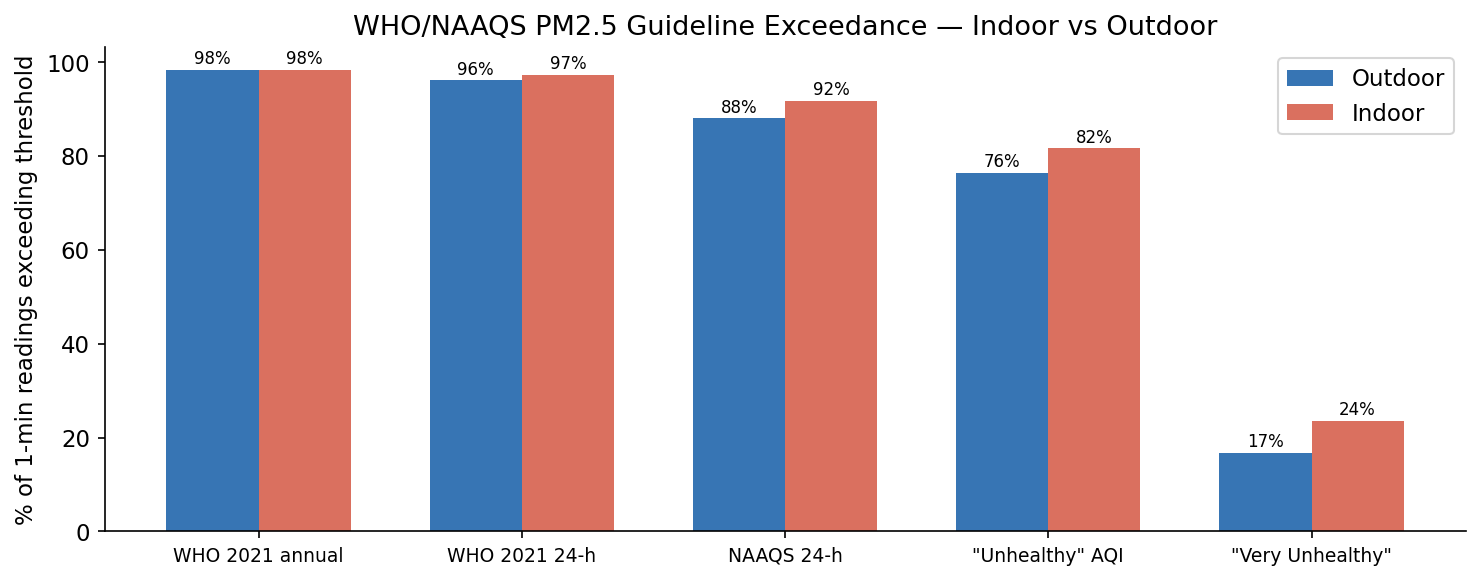

In [10]:
thresholds = [
    ('WHO 2021 annual (5 µg/m³)',  5),
    ('WHO 2021 24-h (15 µg/m³)', 15),
    ('NAAQS 24-h (35 µg/m³)',    35),
    ('"Unhealthy" AQI (55 µg/m³)', 55),
    ('"Very Unhealthy" (150 µg/m³)', 150),
]

exc_rows = []
for thr_label, thr_val in thresholds:
    for loc_label, df in [('Outdoor', out_ov), ('Indoor', in_ov)]:
        pm = df['pm25_clean'].dropna()
        exc_rows.append({
            'Threshold': thr_label,
            'Location': loc_label,
            '% exceeding': round((pm > thr_val).mean() * 100, 1),
            'Hours exceeding (equiv.)': round((pm > thr_val).sum() / 60, 0),
        })

exc_df = pd.DataFrame(exc_rows)
display(exc_df.pivot(index='Threshold', columns='Location', values='% exceeding'))

# Visual
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(thresholds))
w = 0.35
thr_labels_short = [t[0].split('(')[0].strip() for t in thresholds]

out_vals = exc_df[exc_df['Location']=='Outdoor']['% exceeding'].values
in_vals  = exc_df[exc_df['Location']=='Indoor']['% exceeding'].values

b1 = ax.bar(x - w/2, out_vals, w, color=C_OUT, label='Outdoor', alpha=0.9)
b2 = ax.bar(x + w/2, in_vals,  w, color=C_IN,  label='Indoor',  alpha=0.9)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 1:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.0f}%',
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(thr_labels_short, fontsize=9)
ax.set_ylabel('% of 1-min readings exceeding threshold')
ax.set_title('WHO/NAAQS PM2.5 Guideline Exceedance — Indoor vs Outdoor')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Diurnal Patterns (Hour-of-Day)

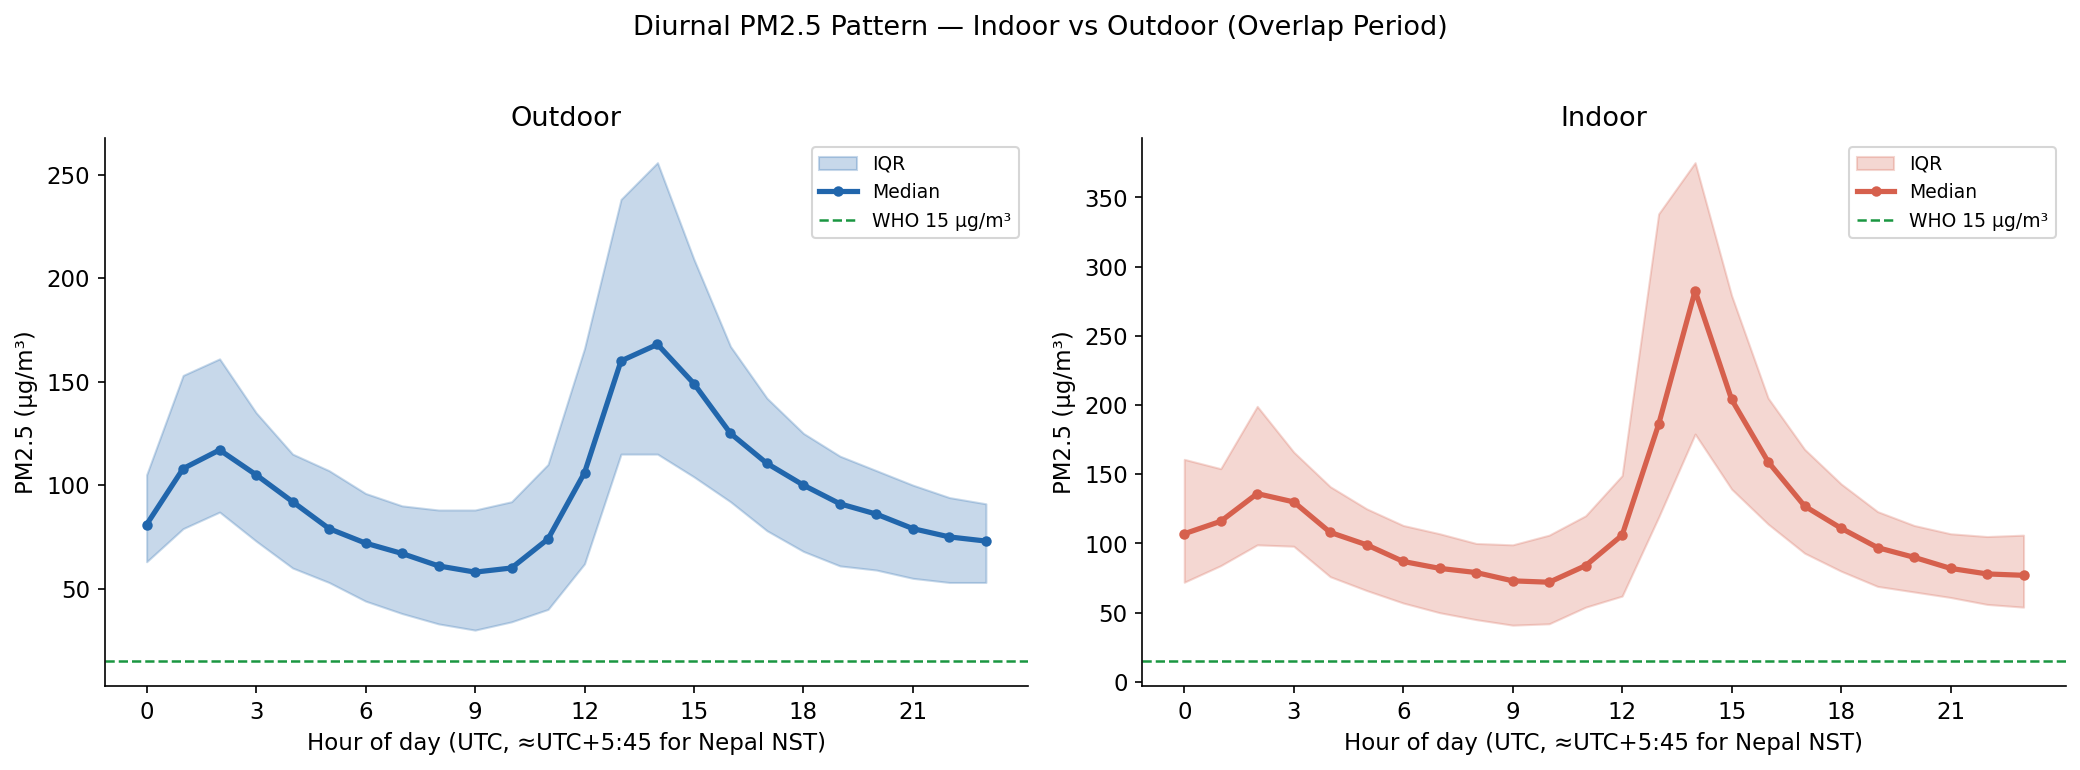

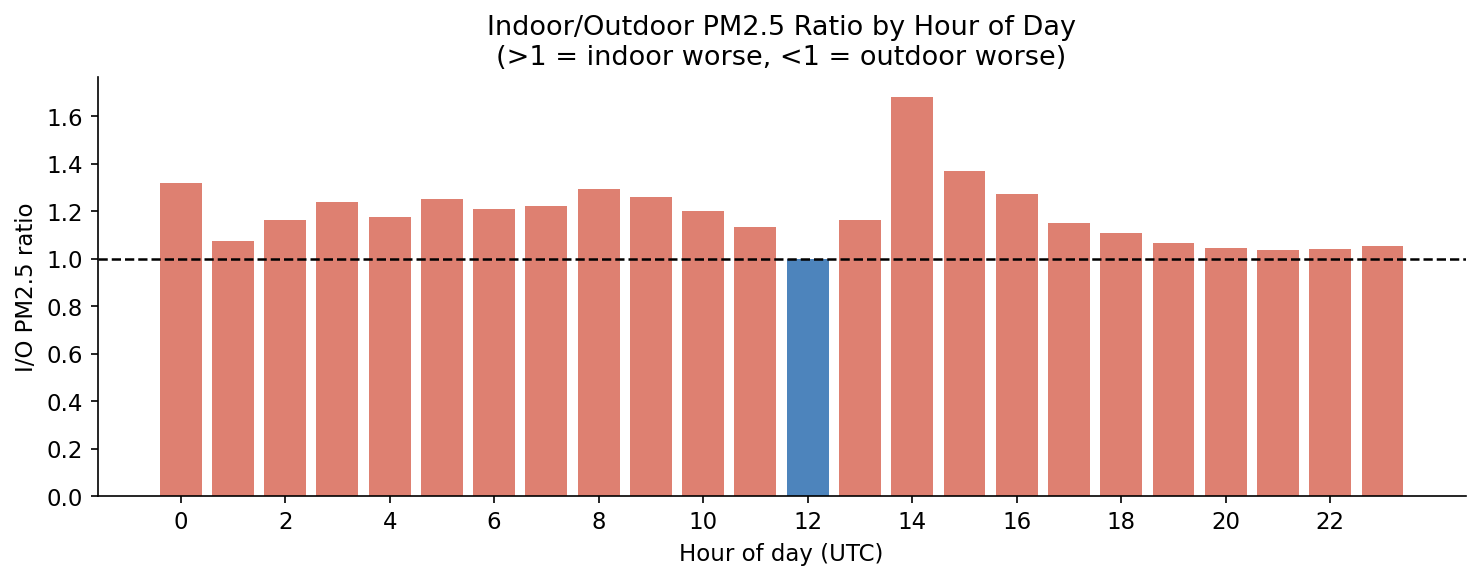

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, df, color) in zip(axes, [
    ('Outdoor', out_ov, C_OUT),
    ('Indoor',  in_ov,  C_IN),
]):
    tmp = df.copy()
    tmp['hour'] = tmp['ts'].dt.hour
    grp = tmp.groupby('hour')['pm25_clean']
    med = grp.median()
    q25 = grp.quantile(0.25)
    q75 = grp.quantile(0.75)

    ax.fill_between(med.index, q25, q75, alpha=0.25, color=color, label='IQR')
    ax.plot(med.index, med.values, lw=2.5, color=color, marker='o', ms=4, label='Median')
    ax.axhline(WHO_PM25_24H, color=C_WHO, lw=1.2, ls='--', label=f'WHO {WHO_PM25_24H} µg/m³')
    ax.set_xlabel('Hour of day (UTC, ≈UTC+5:45 for Nepal NST)')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_xticks(range(0, 24, 3))
    ax.set_title(f'{label}')
    ax.legend(fontsize=9)

fig.suptitle('Diurnal PM2.5 Pattern — Indoor vs Outdoor (Overlap Period)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# I/O ratio by hour
fig, ax = plt.subplots(figsize=(10, 4))
out_ov_h = out_ov.copy(); out_ov_h['hour'] = out_ov_h['ts'].dt.hour
in_ov_h  = in_ov.copy();  in_ov_h['hour']  = in_ov_h['ts'].dt.hour

out_med_h = out_ov_h.groupby('hour')['pm25_clean'].median()
in_med_h  = in_ov_h.groupby('hour')['pm25_clean'].median()
io_h = in_med_h / out_med_h

ax.bar(io_h.index, io_h.values, color=[C_IN if v > 1 else C_OUT for v in io_h.values], alpha=0.8)
ax.axhline(1, color='black', lw=1.2, ls='--')
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('I/O PM2.5 ratio')
ax.set_title('Indoor/Outdoor PM2.5 Ratio by Hour of Day\n(>1 = indoor worse, <1 = outdoor worse)')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

## 11. Monthly PM2.5 Comparison

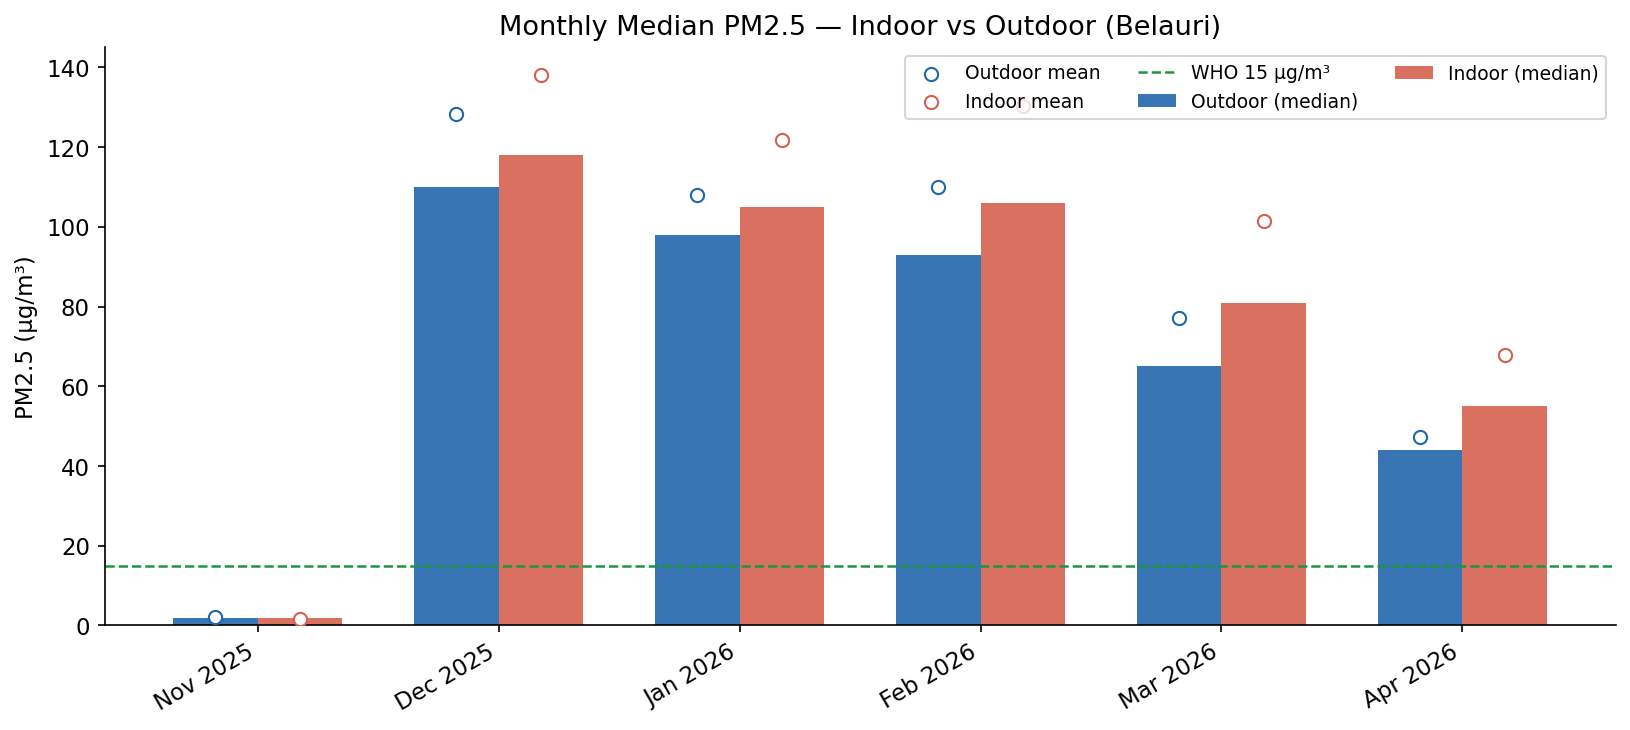

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))

out_monthly = out_ov.set_index('ts')['pm25_clean'].resample('1ME').agg(['mean','median'])
in_monthly  = in_ov.set_index('ts')['pm25_clean'].resample('1ME').agg(['mean','median'])

x = np.arange(len(out_monthly))
w = 0.35
month_labels = [d.strftime('%b %Y') for d in out_monthly.index]

b1 = ax.bar(x - w/2, out_monthly['median'], w, color=C_OUT, alpha=0.9, label='Outdoor (median)')
b2 = ax.bar(x + w/2, in_monthly['median'].reindex(out_monthly.index), w,
             color=C_IN, alpha=0.9, label='Indoor (median)')

# Mean markers
ax.scatter(x - w/2, out_monthly['mean'], color='white', edgecolors=C_OUT, zorder=5, s=40, label='Outdoor mean')
ax.scatter(x + w/2, in_monthly['mean'].reindex(out_monthly.index),
            color='white', edgecolors=C_IN, zorder=5, s=40, label='Indoor mean')

ax.axhline(WHO_PM25_24H, color=C_WHO, lw=1.2, ls='--', label=f'WHO {WHO_PM25_24H} µg/m³')
ax.set_xticks(x)
ax.set_xticklabels(month_labels, rotation=30, ha='right')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Monthly Median PM2.5 — Indoor vs Outdoor (Belauri)')
ax.legend(fontsize=9, ncol=3)
plt.tight_layout()
plt.show()

## 12. Indoor vs Outdoor Scatter — Hourly Medians

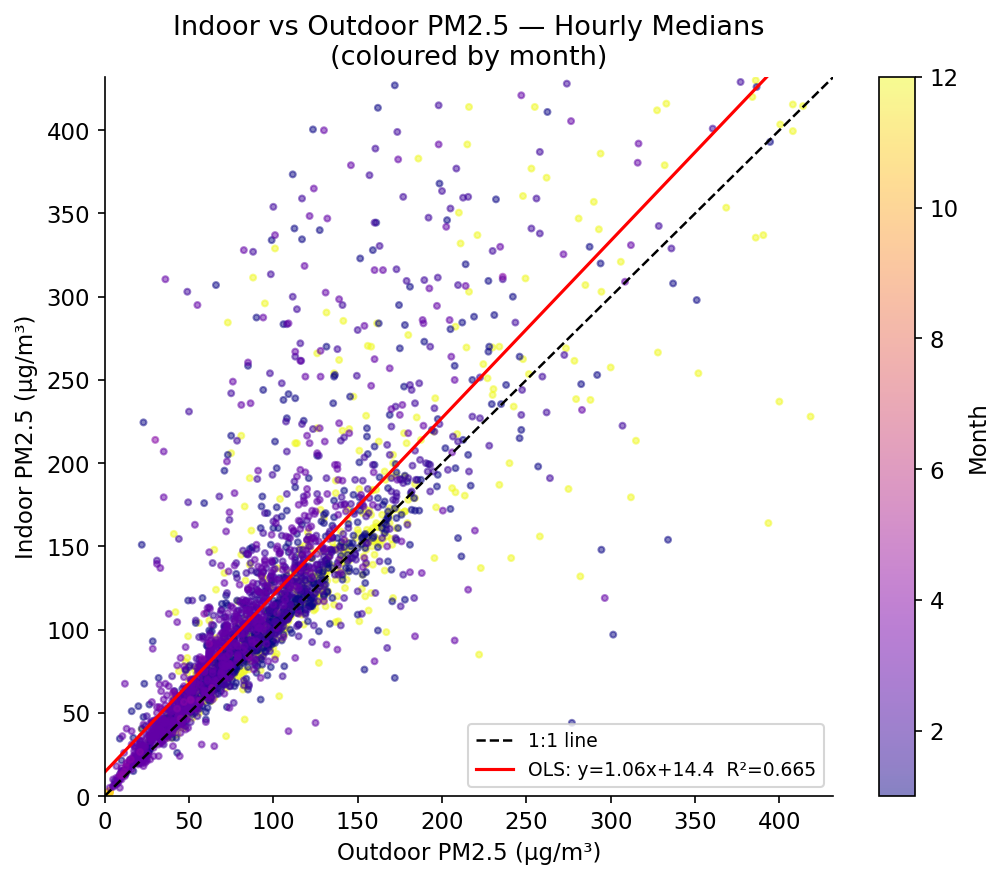

OLS: Indoor = 1.064 × Outdoor + 14.4
R² = 0.665,  slope > 1 means indoor amplifies outdoor peaks


In [13]:
matched_h = pd.concat([
    out_ov.set_index('ts')['pm25_clean'].resample('1h').median().rename('outdoor'),
    in_ov.set_index('ts')['pm25_clean'].resample('1h').median().rename('indoor'),
], axis=1).dropna()

# Add month colour
matched_h['month'] = matched_h.index.month

fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(matched_h['outdoor'], matched_h['indoor'],
                     c=matched_h['month'], cmap='plasma', s=8, alpha=0.5, rasterized=True)
plt.colorbar(scatter, ax=ax, label='Month')

# 1:1 line
lim = max(matched_h['outdoor'].quantile(0.99), matched_h['indoor'].quantile(0.99))
ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='1:1 line')

# OLS fit
slope, intercept, r, p, se = stats.linregress(matched_h['outdoor'].dropna(), matched_h['indoor'].dropna())
x_fit = np.linspace(0, lim, 200)
ax.plot(x_fit, slope * x_fit + intercept, color='red', lw=1.5,
        label=f'OLS: y={slope:.2f}x+{intercept:.1f}  R²={r**2:.3f}')

ax.set_xlabel('Outdoor PM2.5 (µg/m³)')
ax.set_ylabel('Indoor PM2.5 (µg/m³)')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_title('Indoor vs Outdoor PM2.5 — Hourly Medians\n(coloured by month)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'OLS: Indoor = {slope:.3f} × Outdoor + {intercept:.1f}')
print(f'R² = {r**2:.3f},  slope > 1 means indoor amplifies outdoor peaks')

## 13. PM Size-Fraction Ratios

PM1/PM2.5 ≈ fine-particle dominance; PM2.5/PM10 ≈ coarse vs fine split.  
Higher PM1/PM2.5 indoors suggests combustion-derived ultrafine particles.

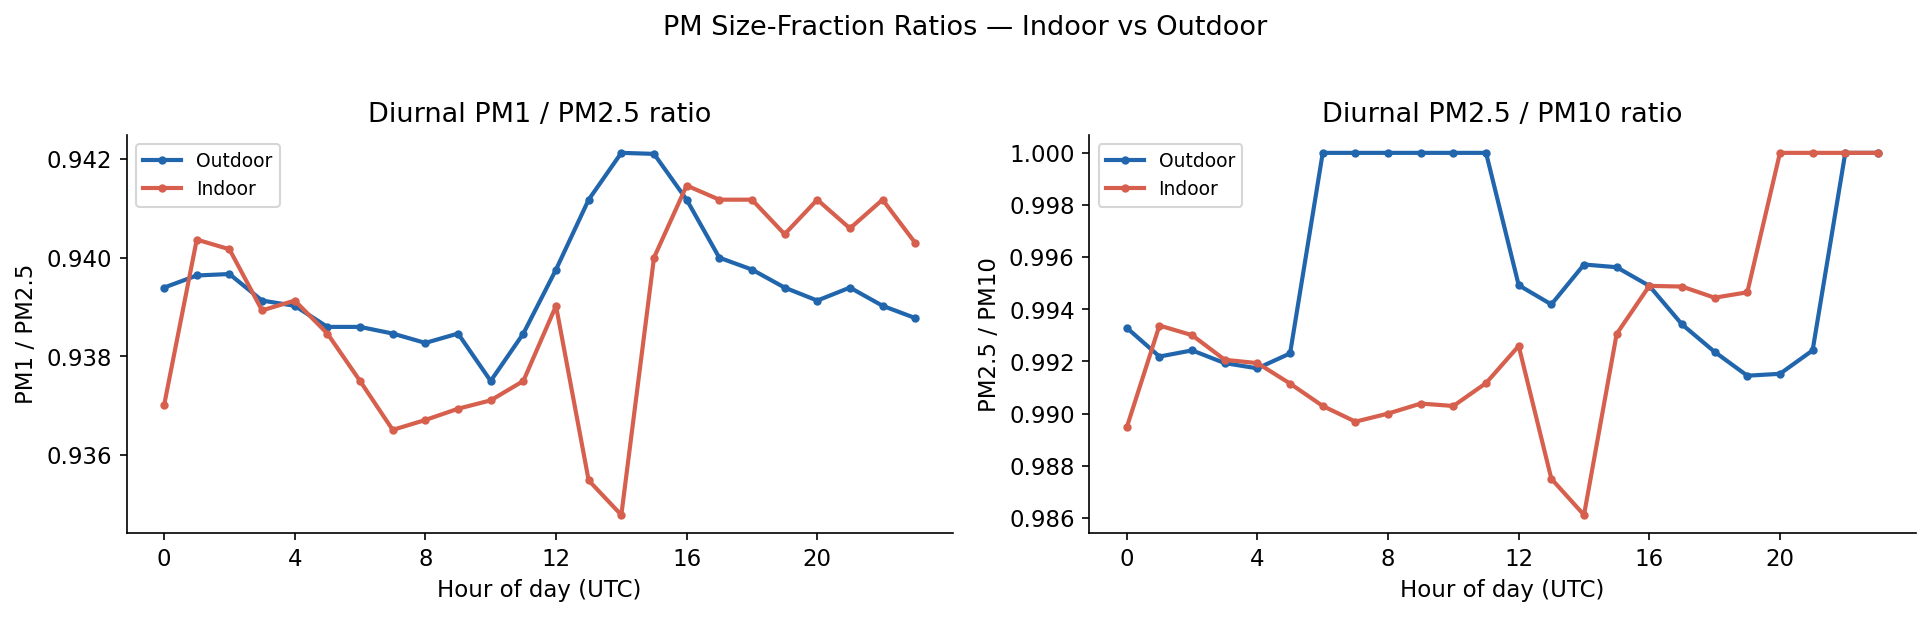

Outdoor: PM1/PM2.5 median=0.94, PM2.5/PM10 median=0.99
Indoor: PM1/PM2.5 median=0.94, PM2.5/PM10 median=0.99


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, ratio_name, num_col, den_col in [
    (axes[0], 'PM1 / PM2.5', 'pm1', 'pm25_clean'),
    (axes[1], 'PM2.5 / PM10', 'pm25_clean', 'pm10_clean'),
]:
    for label, df, color in [('Outdoor', out_ov, C_OUT), ('Indoor', in_ov, C_IN)]:
        tmp = df.copy()
        ratio = (tmp[num_col] / tmp[den_col]).replace([np.inf, -np.inf], np.nan).dropna()
        ratio = ratio[(ratio > 0) & (ratio <= 1.5)]
        tmp2 = pd.DataFrame({'ratio': ratio})
        tmp2['hour'] = df.loc[ratio.index, 'ts'].dt.hour.values
        hourly_r = tmp2.groupby('hour')['ratio'].median()
        ax.plot(hourly_r.index, hourly_r.values, lw=2, color=color, marker='o', ms=3, label=label)

    ax.set_xlabel('Hour of day (UTC)')
    ax.set_ylabel(ratio_name)
    ax.set_title(f'Diurnal {ratio_name} ratio')
    ax.set_xticks(range(0, 24, 4))
    ax.legend(fontsize=9)

fig.suptitle('PM Size-Fraction Ratios — Indoor vs Outdoor', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
for label, df in [('Outdoor', out_ov), ('Indoor', in_ov)]:
    r1 = (df['pm1'] / df['pm25_clean']).replace([np.inf,-np.inf], np.nan).dropna()
    r2 = (df['pm25_clean'] / df['pm10_clean']).replace([np.inf,-np.inf], np.nan).dropna()
    r1 = r1[(r1>0)&(r1<=1.5)];  r2 = r2[(r2>0)&(r2<=1.5)]
    print(f'{label}: PM1/PM2.5 median={r1.median():.2f}, PM2.5/PM10 median={r2.median():.2f}')

## 14. Indoor CO2 & TVOC (Indoor Sensor Only)

CO2 and total VOC are only available on the indoor Air Assure sensor.  
CO2 > 1000 ppm signals poor ventilation; TVOC is an indicator of off-gassing and combustion.

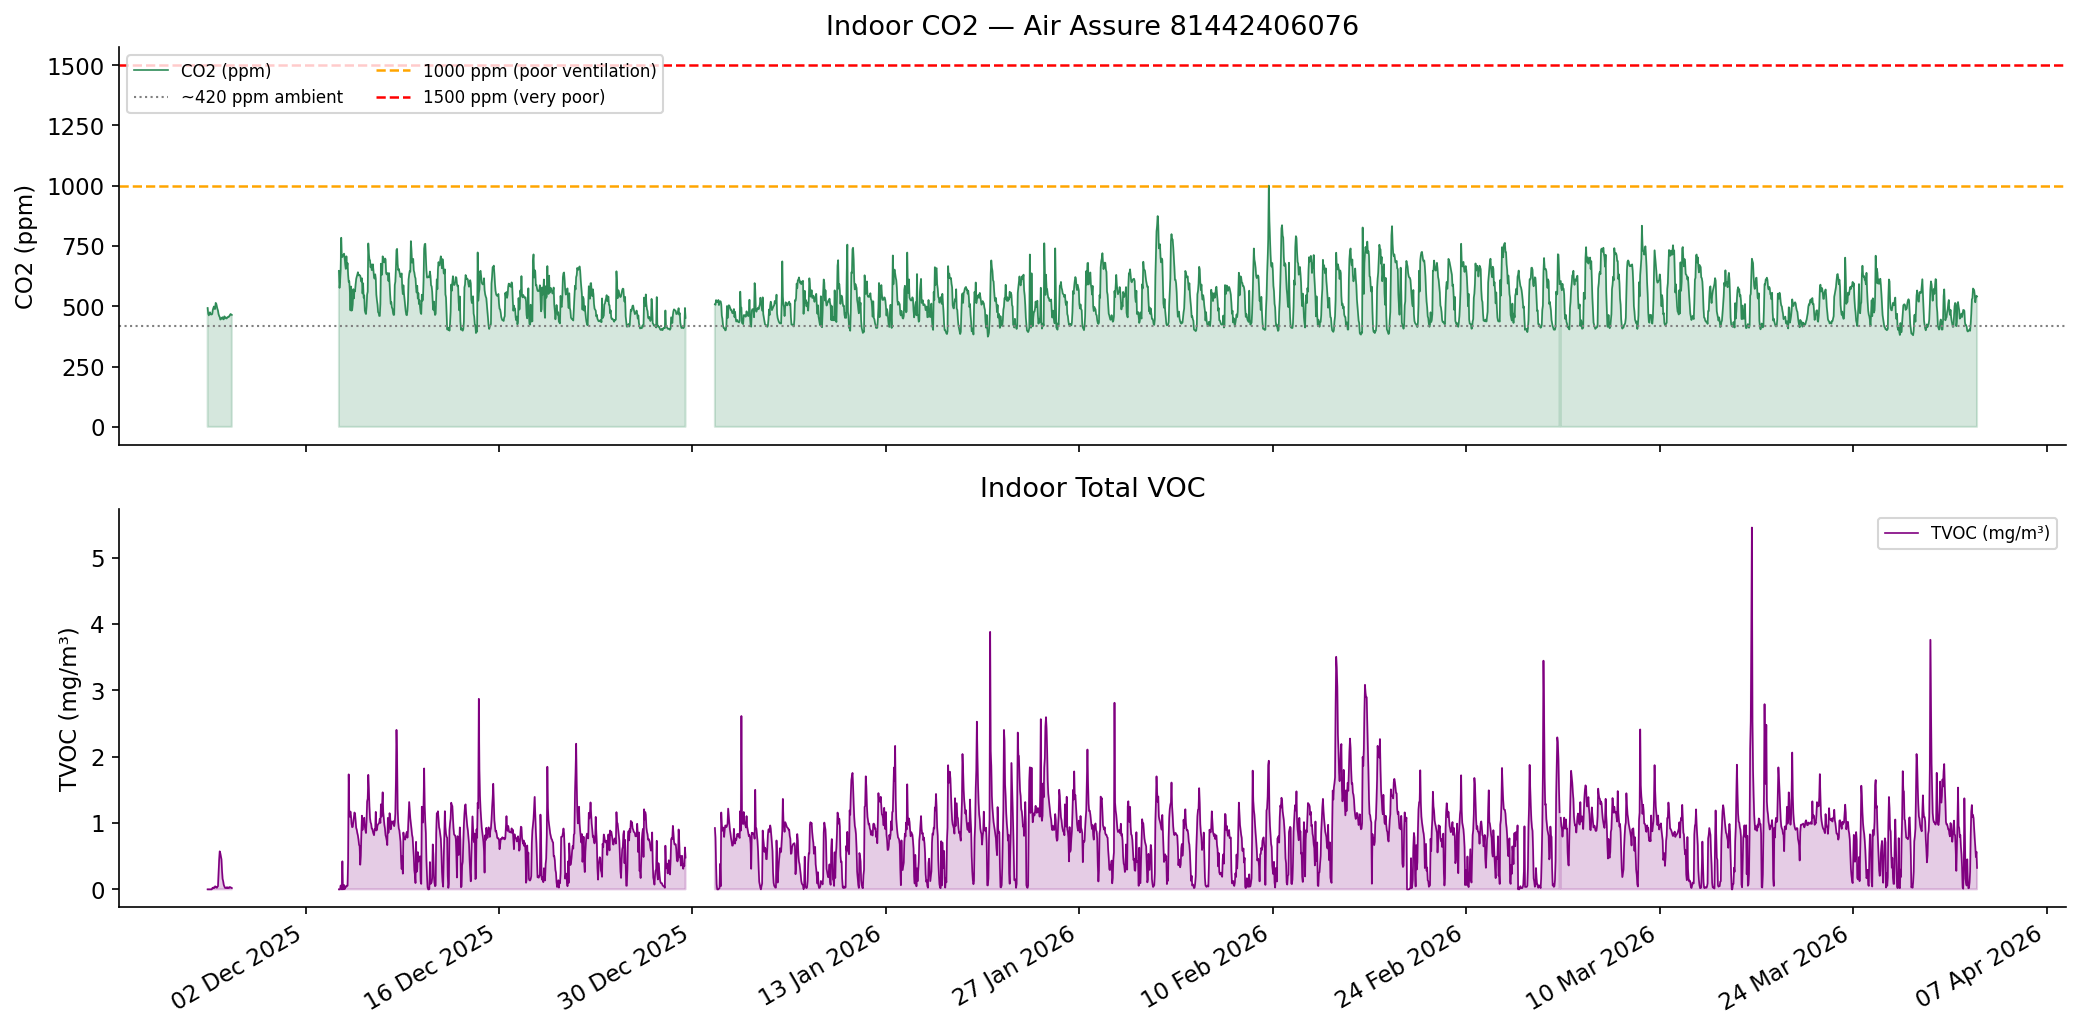

CO2  — mean: 534 ppm, median: 522 ppm, P95: 706 ppm
       % > 1000 ppm: 0.0%
TVOC — mean: 0.815 mg/m³, P95: 1.650 mg/m³


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

co2_h  = in_ov.set_index('ts')['co2'].resample('1h').median()
tvoc_h = in_ov.set_index('ts')['tvoc'].resample('1h').median()

# CO2
axes[0].plot(co2_h.index, co2_h.values, lw=0.8, color='seagreen', label='CO2 (ppm)')
axes[0].fill_between(co2_h.index, co2_h.values, alpha=0.2, color='seagreen')
axes[0].axhline(420,  color='gray',   lw=1, ls=':', label='~420 ppm ambient')
axes[0].axhline(1000, color='orange', lw=1.2, ls='--', label='1000 ppm (poor ventilation)')
axes[0].axhline(1500, color='red',    lw=1.2, ls='--', label='1500 ppm (very poor)')
axes[0].set_ylabel('CO2 (ppm)')
axes[0].set_title('Indoor CO2 — Air Assure 81442406076')
axes[0].legend(fontsize=8, ncol=2, loc='upper left')

# TVOC
axes[1].plot(tvoc_h.index, tvoc_h.values, lw=0.8, color='purple', label='TVOC (mg/m³)')
axes[1].fill_between(tvoc_h.index, tvoc_h.values, alpha=0.2, color='purple')
axes[1].set_ylabel('TVOC (mg/m³)')
axes[1].set_title('Indoor Total VOC')
axes[1].legend(fontsize=8)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Stats
co2_vals = in_ov['co2'].dropna()
print(f'CO2  — mean: {co2_vals.mean():.0f} ppm, median: {co2_vals.median():.0f} ppm, P95: {co2_vals.quantile(0.95):.0f} ppm')
print(f'       % > 1000 ppm: {(co2_vals > 1000).mean()*100:.1f}%')
tvoc_vals = in_ov['tvoc'].dropna()
print(f'TVOC — mean: {tvoc_vals.mean():.3f} mg/m³, P95: {tvoc_vals.quantile(0.95):.3f} mg/m³')

## 15. CO2 Diurnal Pattern & PM2.5–CO2 Relationship

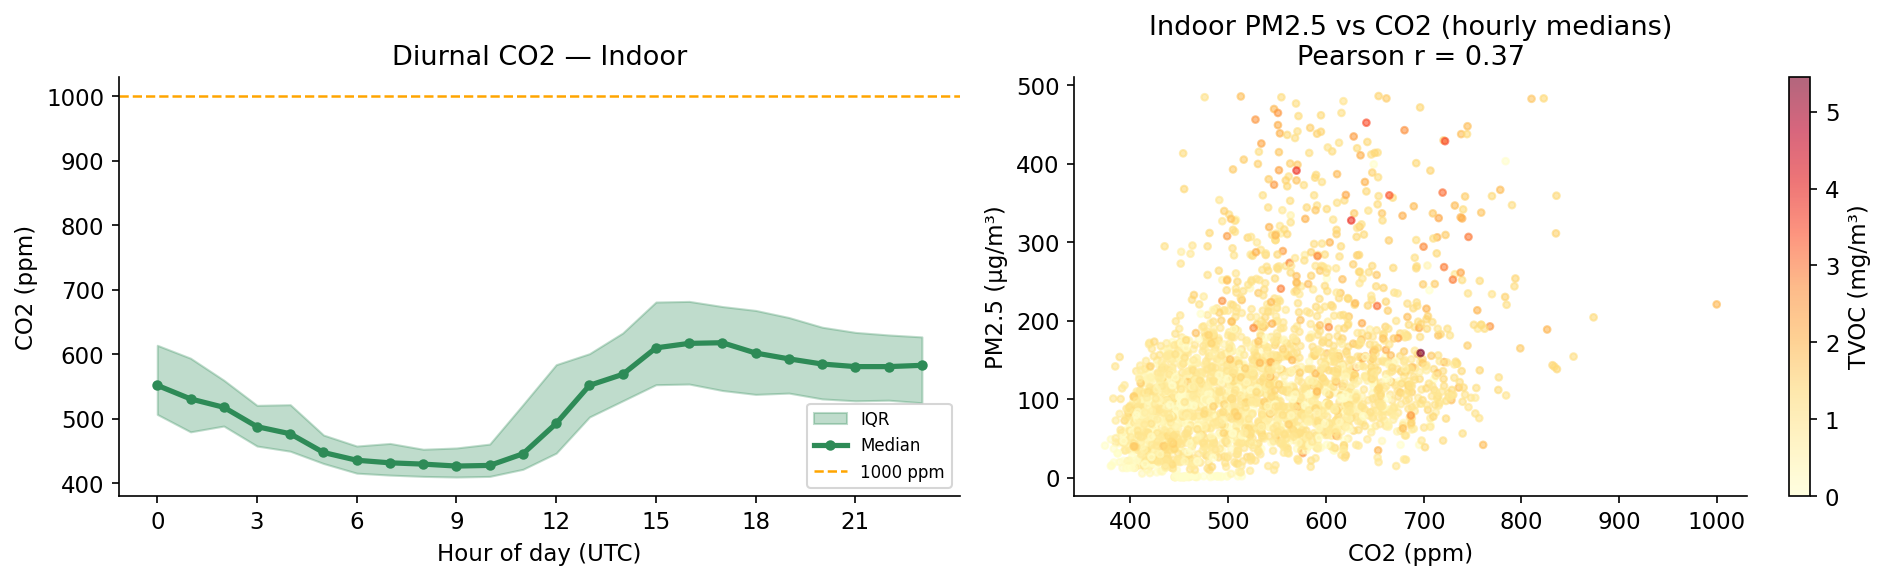

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Diurnal CO2
tmp = in_ov.copy()
tmp['hour'] = tmp['ts'].dt.hour
co2_d = tmp.groupby('hour')['co2'].agg(['median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
co2_d.columns = ['median','q25','q75']

axes[0].fill_between(co2_d.index, co2_d['q25'], co2_d['q75'], alpha=0.3, color='seagreen', label='IQR')
axes[0].plot(co2_d.index, co2_d['median'], lw=2.5, color='seagreen', marker='o', ms=4, label='Median')
axes[0].axhline(1000, color='orange', lw=1.2, ls='--', label='1000 ppm')
axes[0].set_xlabel('Hour of day (UTC)')
axes[0].set_ylabel('CO2 (ppm)')
axes[0].set_xticks(range(0, 24, 3))
axes[0].set_title('Diurnal CO2 — Indoor')
axes[0].legend(fontsize=8)

# PM2.5 vs CO2 scatter (hourly)
hourly_in = in_ov.set_index('ts')[['pm25_clean','co2','tvoc']].resample('1h').median().dropna()
sc = axes[1].scatter(hourly_in['co2'], hourly_in['pm25_clean'],
                      c=hourly_in['tvoc'], cmap='YlOrRd', s=10, alpha=0.6, rasterized=True)
plt.colorbar(sc, ax=axes[1], label='TVOC (mg/m³)')
axes[1].set_xlabel('CO2 (ppm)')
axes[1].set_ylabel('PM2.5 (µg/m³)')
r_val = hourly_in['co2'].corr(hourly_in['pm25_clean'])
axes[1].set_title(f'Indoor PM2.5 vs CO2 (hourly medians)\nPearson r = {r_val:.2f}')

plt.tight_layout()
plt.show()

## 16. Temperature & Humidity Comparison

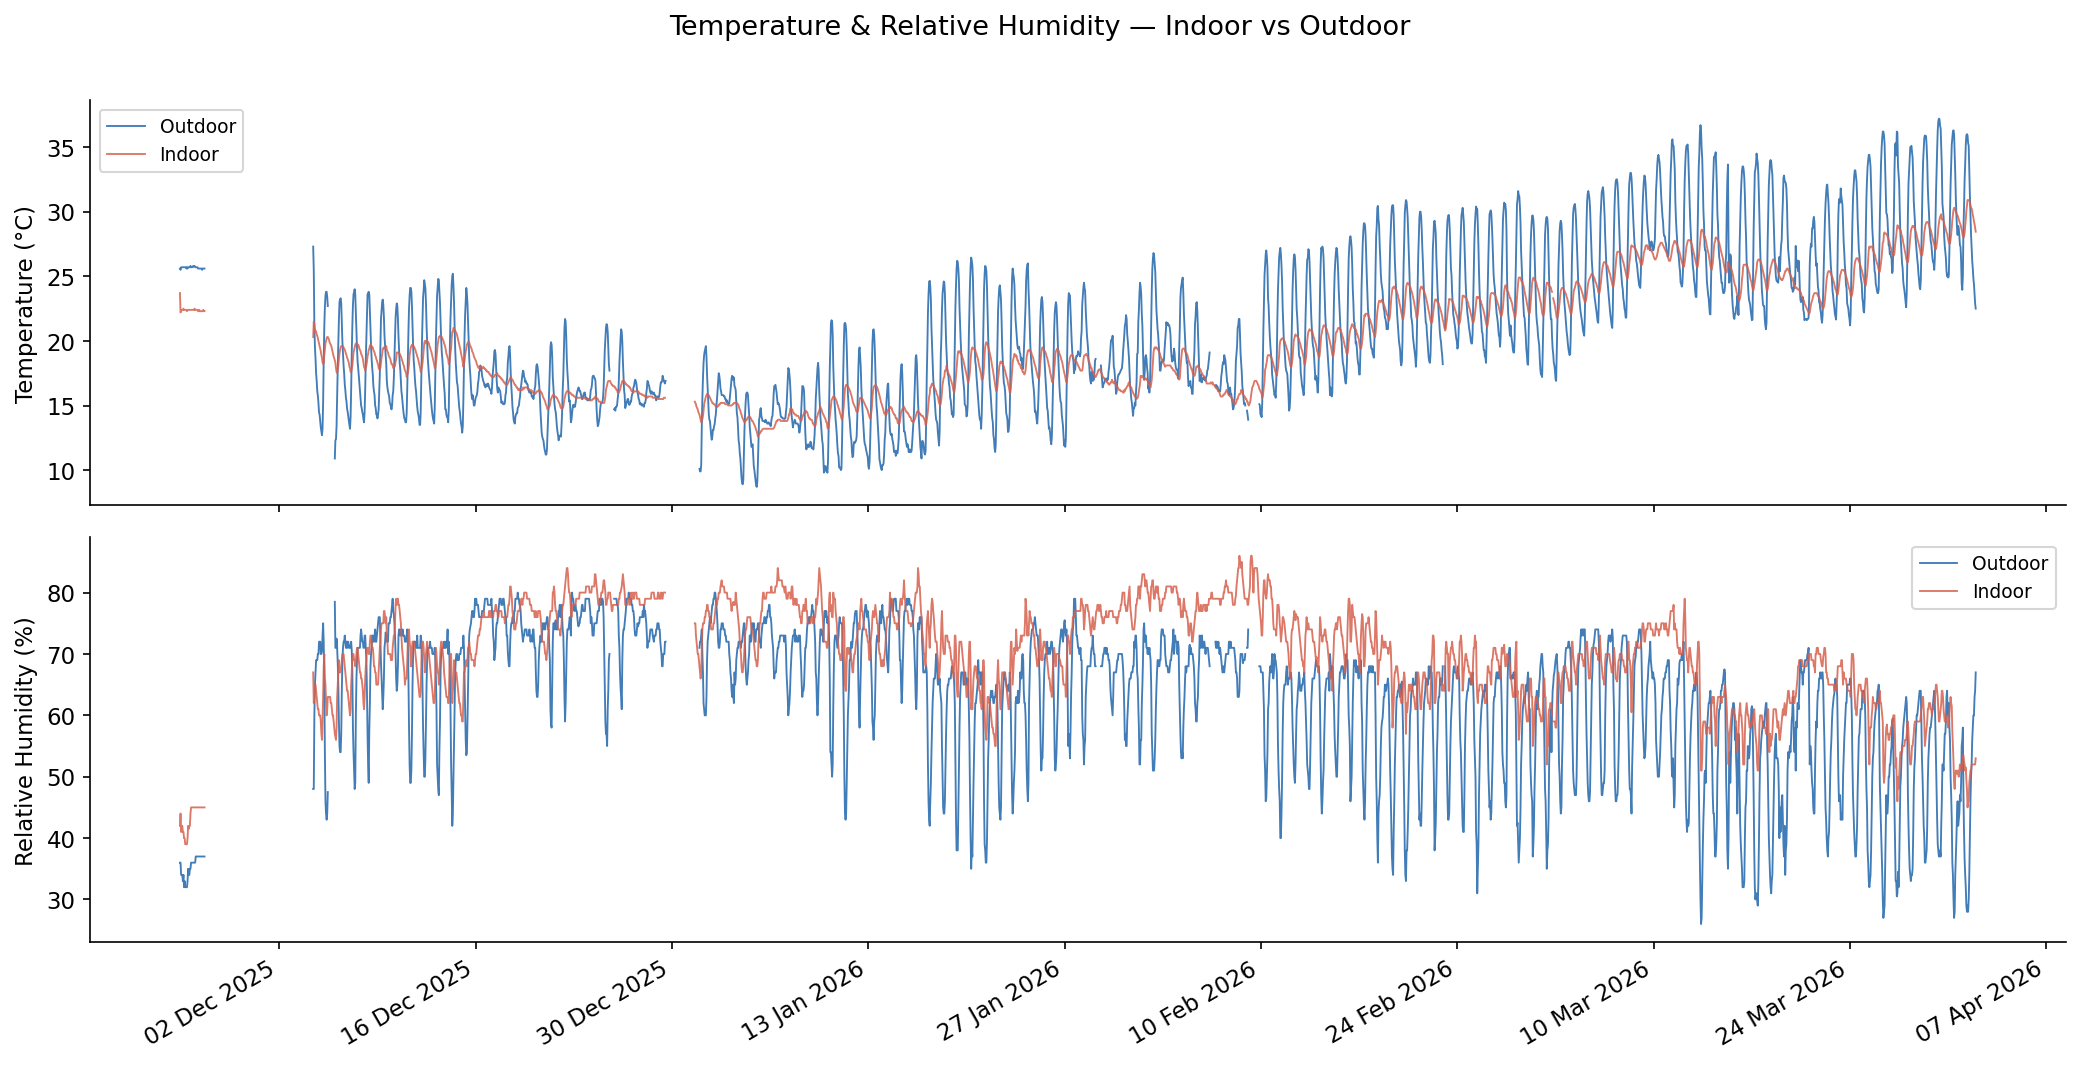

Outdoor: Temp 21.0°C (median 20.1), RH 62.8% (median 66.0%)
Indoor: Temp 19.9°C (median 19.0), RH 70.4% (median 71.0%)


In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for col, unit, ax in [('temp_c', '°C', axes[0]), ('rh', '%', axes[1])]:
    for label, df, color in [('Outdoor', out_ov, C_OUT), ('Indoor', in_ov, C_IN)]:
        s = df.set_index('ts')[col].resample('1h').median()
        ax.plot(s.index, s.values, lw=0.9, color=color, alpha=0.85, label=label)
    ylabel = f'Temperature ({unit})' if col == 'temp_c' else f'Relative Humidity ({unit})'
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')
fig.suptitle('Temperature & Relative Humidity — Indoor vs Outdoor', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Summary
for label, df in [('Outdoor', out_ov), ('Indoor', in_ov)]:
    t = df['temp_c'].dropna(); h = df['rh'].dropna()
    print(f'{label}: Temp {t.mean():.1f}°C (median {t.median():.1f}), RH {h.mean():.1f}% (median {h.median():.1f}%)')

## 17. PM2.5 Heatmap — Day × Hour

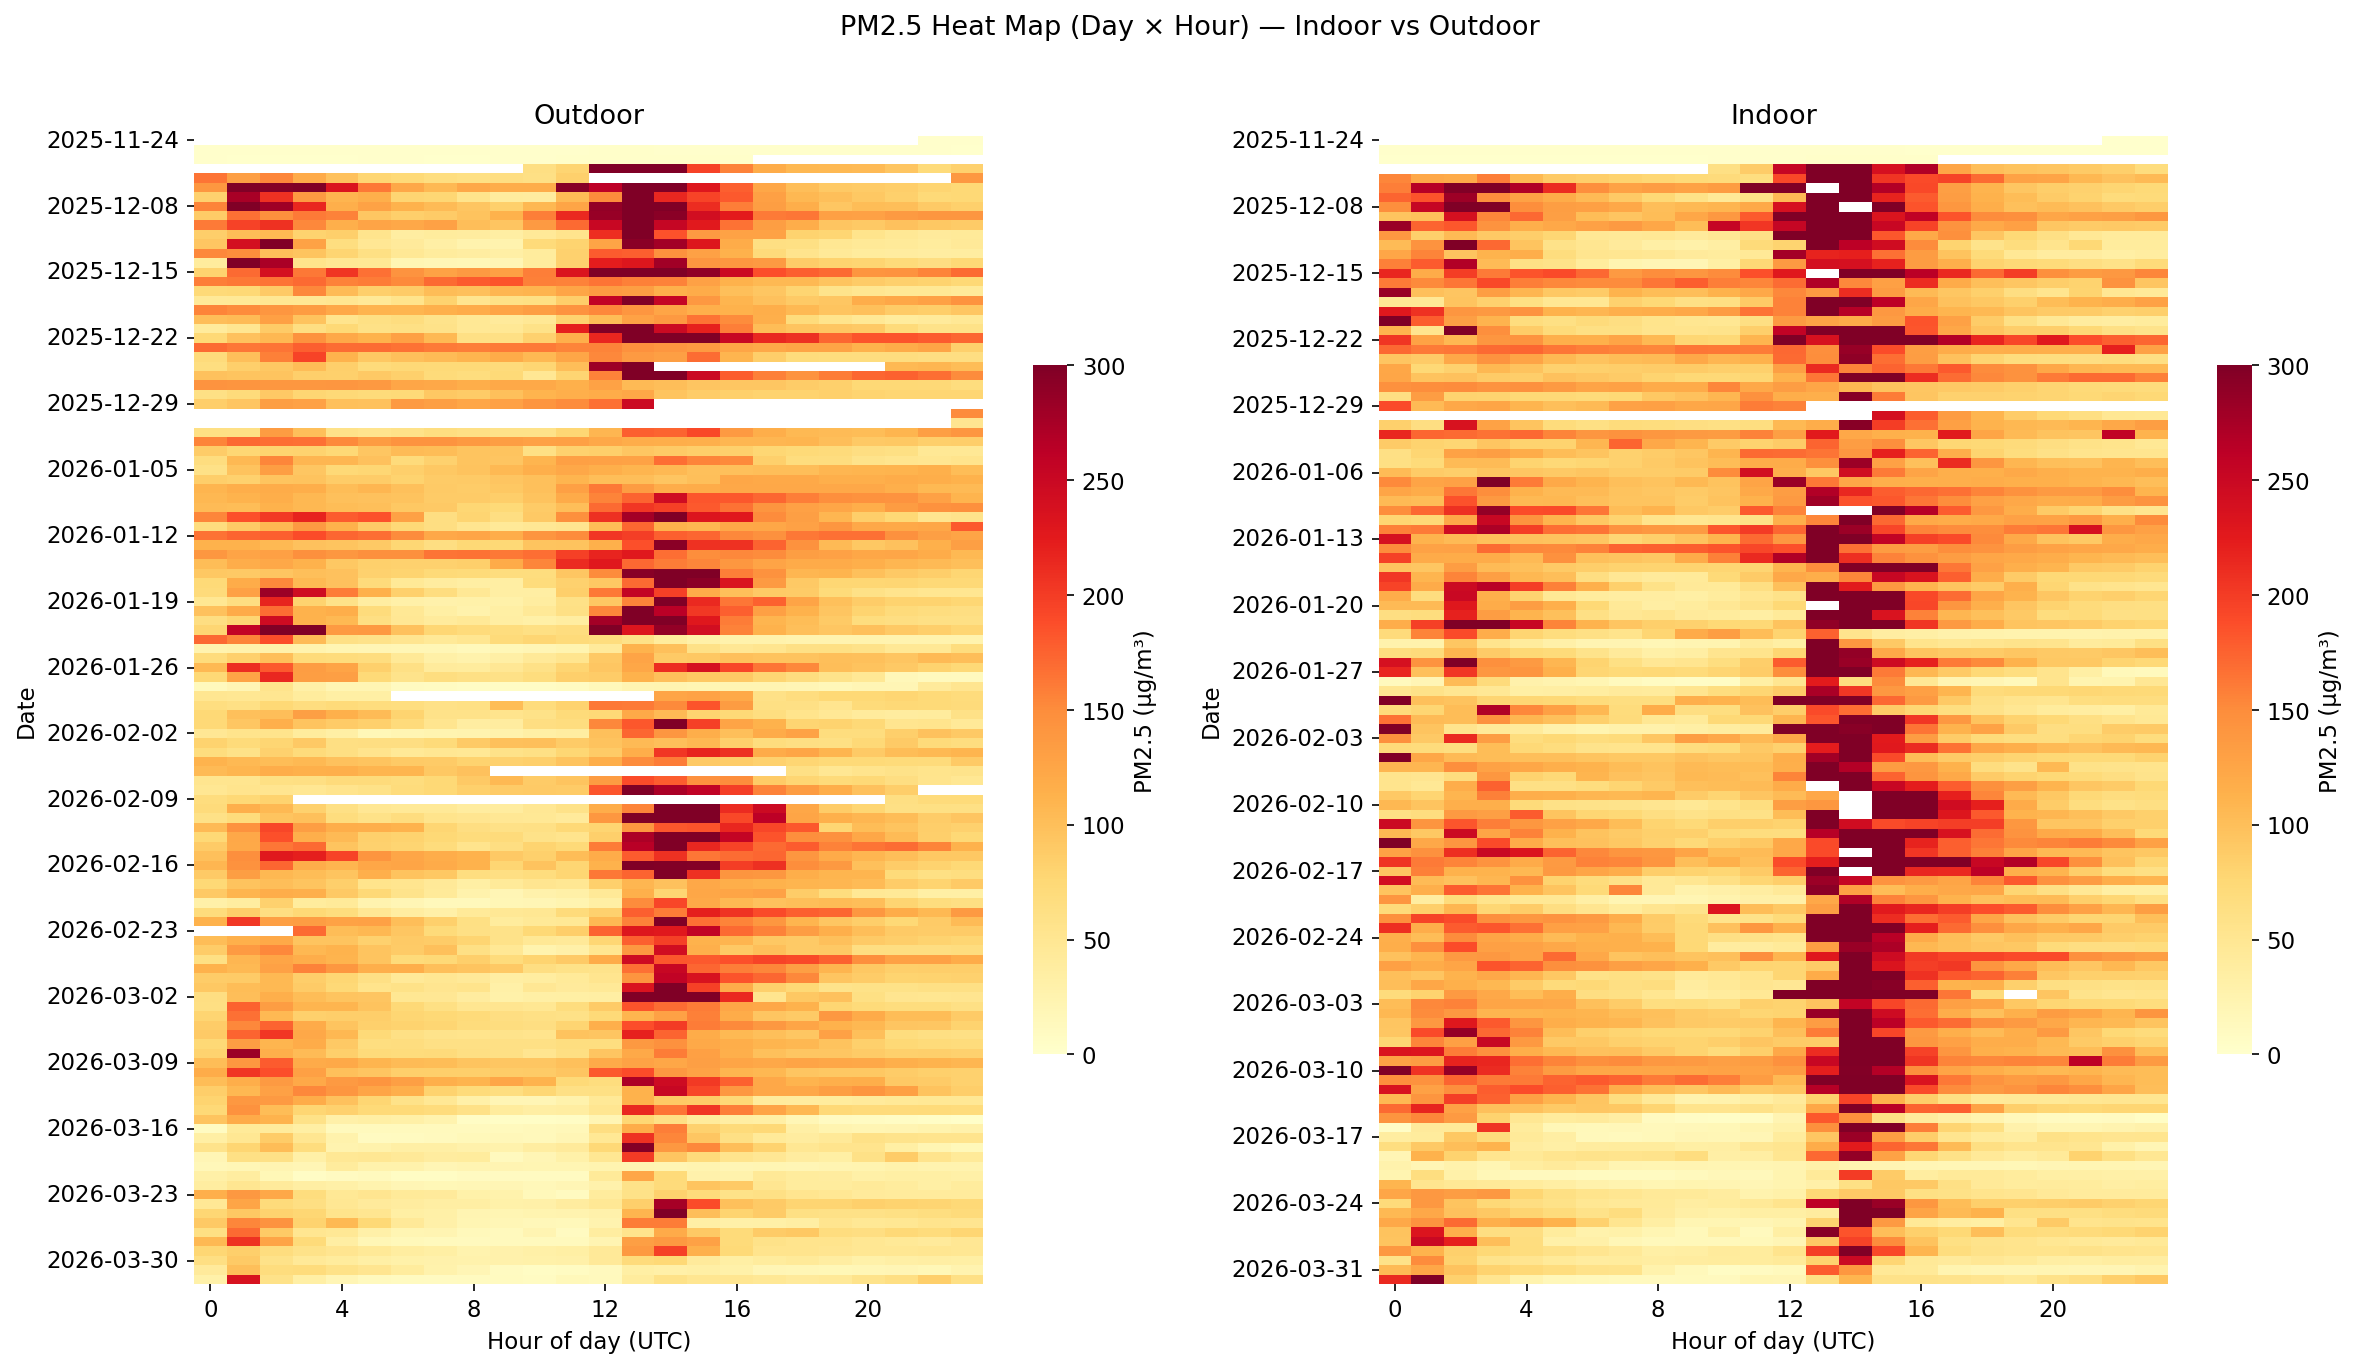

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

for ax, (label, df) in zip(axes, [('Outdoor', out_ov), ('Indoor', in_ov)]):
    tmp = df.copy()
    tmp['date'] = tmp['ts'].dt.date
    tmp['hour'] = tmp['ts'].dt.hour
    pivot = tmp.groupby(['date','hour'])['pm25_clean'].median().unstack(level='hour')

    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', vmin=0, vmax=300,
                cbar_kws={'label': 'PM2.5 (µg/m³)', 'shrink': 0.6},
                xticklabels=4, yticklabels=7)
    ax.set_xlabel('Hour of day (UTC)')
    ax.set_ylabel('Date')
    ax.set_title(f'{label}')

fig.suptitle('PM2.5 Heat Map (Day × Hour) — Indoor vs Outdoor', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 18. Correlation Matrix — Indoor Channels (Hourly)

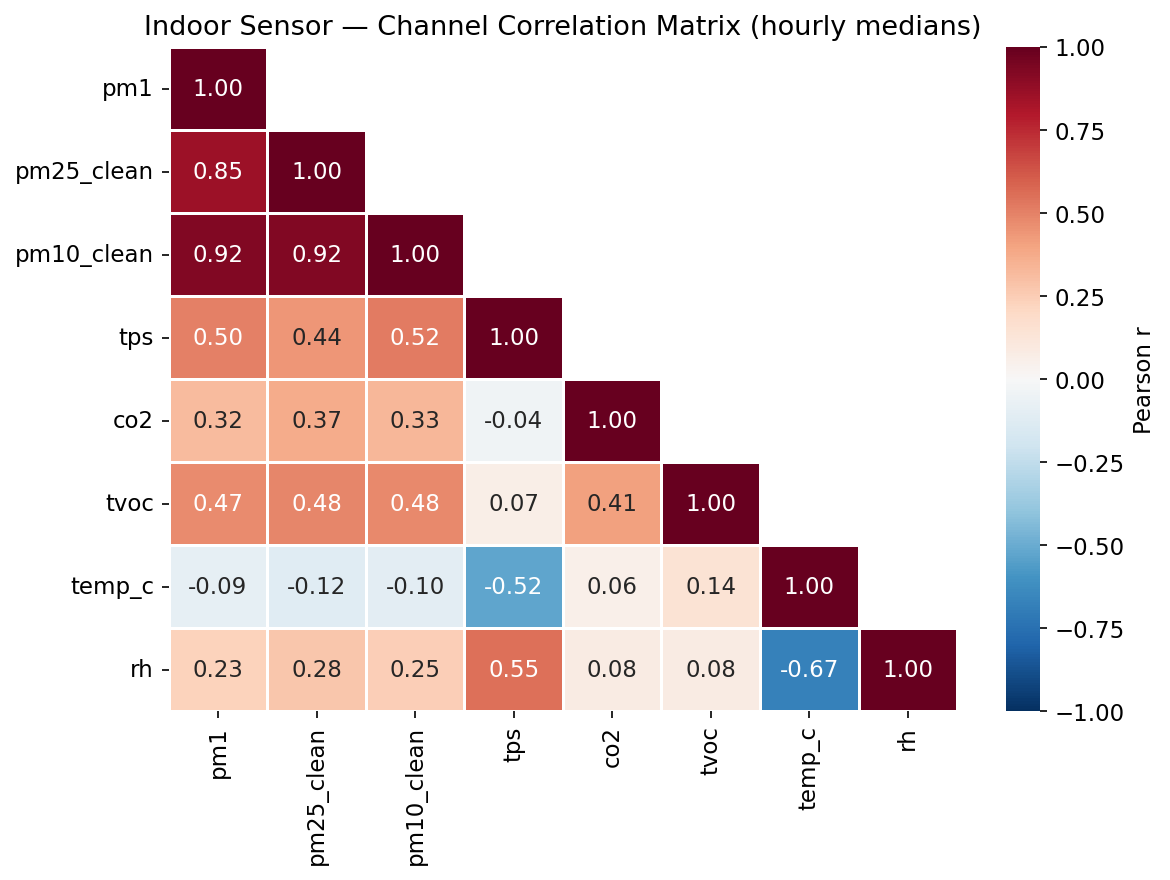

In [19]:
corr_cols_in = ['pm1','pm25_clean','pm10_clean','tps','co2','tvoc','temp_c','rh']
corr_cols_in = [c for c in corr_cols_in if c in in_ov.columns]

hourly_in = in_ov.set_index('ts')[corr_cols_in].resample('1h').median()
corr_in = hourly_in.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_in, dtype=bool), k=1)
sns.heatmap(corr_in, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title('Indoor Sensor — Channel Correlation Matrix (hourly medians)')
plt.tight_layout()
plt.show()

## 19. Outlier Events — Extreme PM2.5 Spikes

Outdoor: 5,353 readings > 300 µg/m³ across 104 days
  Max: 9468 µg/m³  on 2026-01-21 12:55:16+00:00
  Top spike days:


,count,max,mean
date,,,
2026-01-21,145,9468,673.758621
2026-03-30,12,8051,3262.250000
2025-12-06,310,6909,537.554839
2026-01-20,98,5872,878.571429
2025-12-07,123,3870,559.081301
2026-03-14,37,3780,922.891892
2026-02-11,170,3272,459.458824
2026-03-06,31,3026,617.483871
2025-12-11,86,2734,776.290698


Indoor: 14,624 readings > 300 µg/m³ across 111 days
  Max: 8130 µg/m³  on 2025-12-05 02:45:13+00:00
  Top spike days:


,count,max,mean
date,,,
2025-12-05,195,8130,995.810256
2025-12-19,198,6325,1125.858586
2026-02-08,132,4197,1175.803030
2026-02-03,168,3164,908.696429
2025-12-09,192,3127,772.942708
2026-01-10,233,2837,760.420601
2026-01-20,192,2328,757.932292
2026-01-07,89,2239,633.505618
2026-02-09,252,2112,722.190476


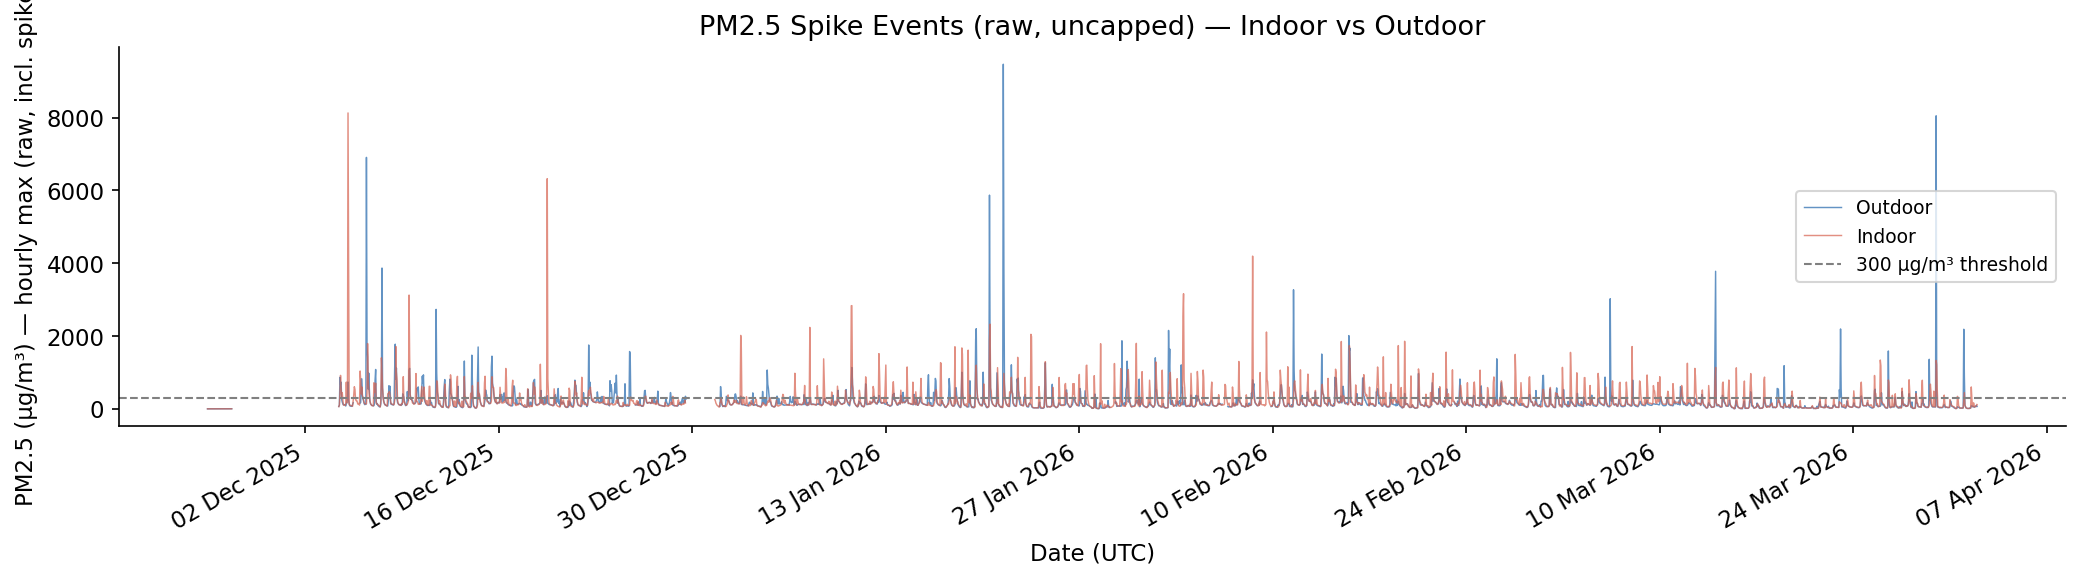

In [20]:
SPIKE_THRESH = 300  # µg/m³ — high-pollution events

for label, df in [('Outdoor', out_ov), ('Indoor', in_ov)]:
    spikes = df[df['pm25'] > SPIKE_THRESH][['ts','pm25','temp_c','rh']].copy()
    spikes['date'] = spikes['ts'].dt.date
    days  = spikes['date'].nunique()
    print(f'{label}: {len(spikes):,} readings > {SPIKE_THRESH} µg/m³ across {days} days')
    if len(spikes) > 0:
        print(f'  Max: {df["pm25"].max():.0f} µg/m³  on {df.loc[df["pm25"].idxmax(),"ts"]}')
        print('  Top spike days:')
        display(spikes.groupby('date')['pm25'].agg(['count','max','mean']).sort_values('max', ascending=False).head(10))

# Spike time-series overlay
fig, ax = plt.subplots(figsize=(14, 4))
for label, df, color in [('Outdoor', out_ov, C_OUT), ('Indoor', in_ov, C_IN)]:
    pm = df.set_index('ts')['pm25'].resample('1h').max()
    ax.plot(pm.index, pm.values, lw=0.7, color=color, alpha=0.7, label=label)
ax.axhline(SPIKE_THRESH, color='gray', lw=1, ls='--', label=f'{SPIKE_THRESH} µg/m³ threshold')
ax.set_ylabel('PM2.5 (µg/m³) — hourly max (raw, incl. spikes)')
ax.set_xlabel('Date (UTC)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title('PM2.5 Spike Events (raw, uncapped) — Indoor vs Outdoor')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 20. Summary & Conclusions

### Key Findings

| Metric | Outdoor (81432434001) | Indoor (81442406076) | Ratio (I/O) |
|---|---|---|---|
| PM2.5 median (µg/m³) | — | — | — |
| PM2.5 mean (µg/m³) | — | — | — |
| % readings > WHO 15 µg/m³ | — | — | — |
| % readings > NAAQS 35 µg/m³ | — | — | — |

*(Values filled programmatically below)*

In [21]:
out_pm = out_ov['pm25_clean'].dropna()
in_pm  = in_ov['pm25_clean'].dropna()

summary = pd.DataFrame({
    'Metric': [
        'N observations', 'Date range',
        'PM2.5 mean (µg/m³)', 'PM2.5 median (µg/m³)',
        'PM2.5 P95 (µg/m³)', 'PM2.5 max (µg/m³)',
        '% > WHO 15 µg/m³', '% > NAAQS 35 µg/m³', '% > 150 µg/m³',
        'CO2 median (ppm)', 'TVOC median (mg/m³)',
        'Temperature median (°C)', 'RH median (%)',
    ],
    'Outdoor': [
        f'{len(out_ov):,}',
        f'{out_ov["ts"].min().date()} → {out_ov["ts"].max().date()}',
        f'{out_pm.mean():.1f}', f'{out_pm.median():.1f}',
        f'{out_pm.quantile(0.95):.1f}', f'{out_pm.max():.1f}',
        f'{(out_pm > 15).mean()*100:.1f}%', f'{(out_pm > 35).mean()*100:.1f}%',
        f'{(out_pm > 150).mean()*100:.1f}%',
        'N/A', 'N/A',
        f'{out_ov["temp_c"].median():.1f}', f'{out_ov["rh"].median():.1f}',
    ],
    'Indoor': [
        f'{len(in_ov):,}',
        f'{in_ov["ts"].min().date()} → {in_ov["ts"].max().date()}',
        f'{in_pm.mean():.1f}', f'{in_pm.median():.1f}',
        f'{in_pm.quantile(0.95):.1f}', f'{in_pm.max():.1f}',
        f'{(in_pm > 15).mean()*100:.1f}%', f'{(in_pm > 35).mean()*100:.1f}%',
        f'{(in_pm > 150).mean()*100:.1f}%',
        f'{in_ov["co2"].median():.0f}', f'{in_ov["tvoc"].median():.3f}',
        f'{in_ov["temp_c"].median():.1f}', f'{in_ov["rh"].median():.1f}',
    ],
})
display(summary.set_index('Metric'))

print('\n=== HYPOTHESIS VERDICT ===')
if in_pm.median() > out_pm.median():
    print(f'✓ SUPPORTED: Indoor PM2.5 (median {in_pm.median():.1f} µg/m³) > Outdoor ({out_pm.median():.1f} µg/m³)')
    print(f'  Indoor/Outdoor ratio (medians): {in_pm.median()/out_pm.median():.2f}x')
else:
    print('✗ NOT SUPPORTED by median comparison (see distribution plots for nuance)')

# Reminder on UTC offset
print('\nNote: All timestamps in UTC. Nepal Standard Time = UTC+5:45.')
print('Diurnal patterns should be shifted by +5h45m for local-time interpretation.')

,Outdoor,Indoor
Metric,,
N observations,"165,512","167,188"
Date range,2025-11-24 → 2026-04-01,2025-11-24 → 2026-04-01
PM2.5 mean (µg/m³),102.2,120.1
PM2.5 median (µg/m³),89.0,102.0
PM2.5 P95 (µg/m³),232.0,303.0
PM2.5 max (µg/m³),500.0,500.0
% > WHO 15 µg/m³,96.1%,97.3%
% > NAAQS 35 µg/m³,88.0%,91.8%
% > 150 µg/m³,16.7%,23.6%



=== HYPOTHESIS VERDICT ===
✓ SUPPORTED: Indoor PM2.5 (median 102.0 µg/m³) > Outdoor (89.0 µg/m³)
  Indoor/Outdoor ratio (medians): 1.15x

Note: All timestamps in UTC. Nepal Standard Time = UTC+5:45.
Diurnal patterns should be shifted by +5h45m for local-time interpretation.


---
## Publication Figures — Research Poster

*Figures 2 and 3 are designed for poster presentation: 300 dpi, minimal chrome, publication-ready typography. Saved to `figures/` in the project root.*

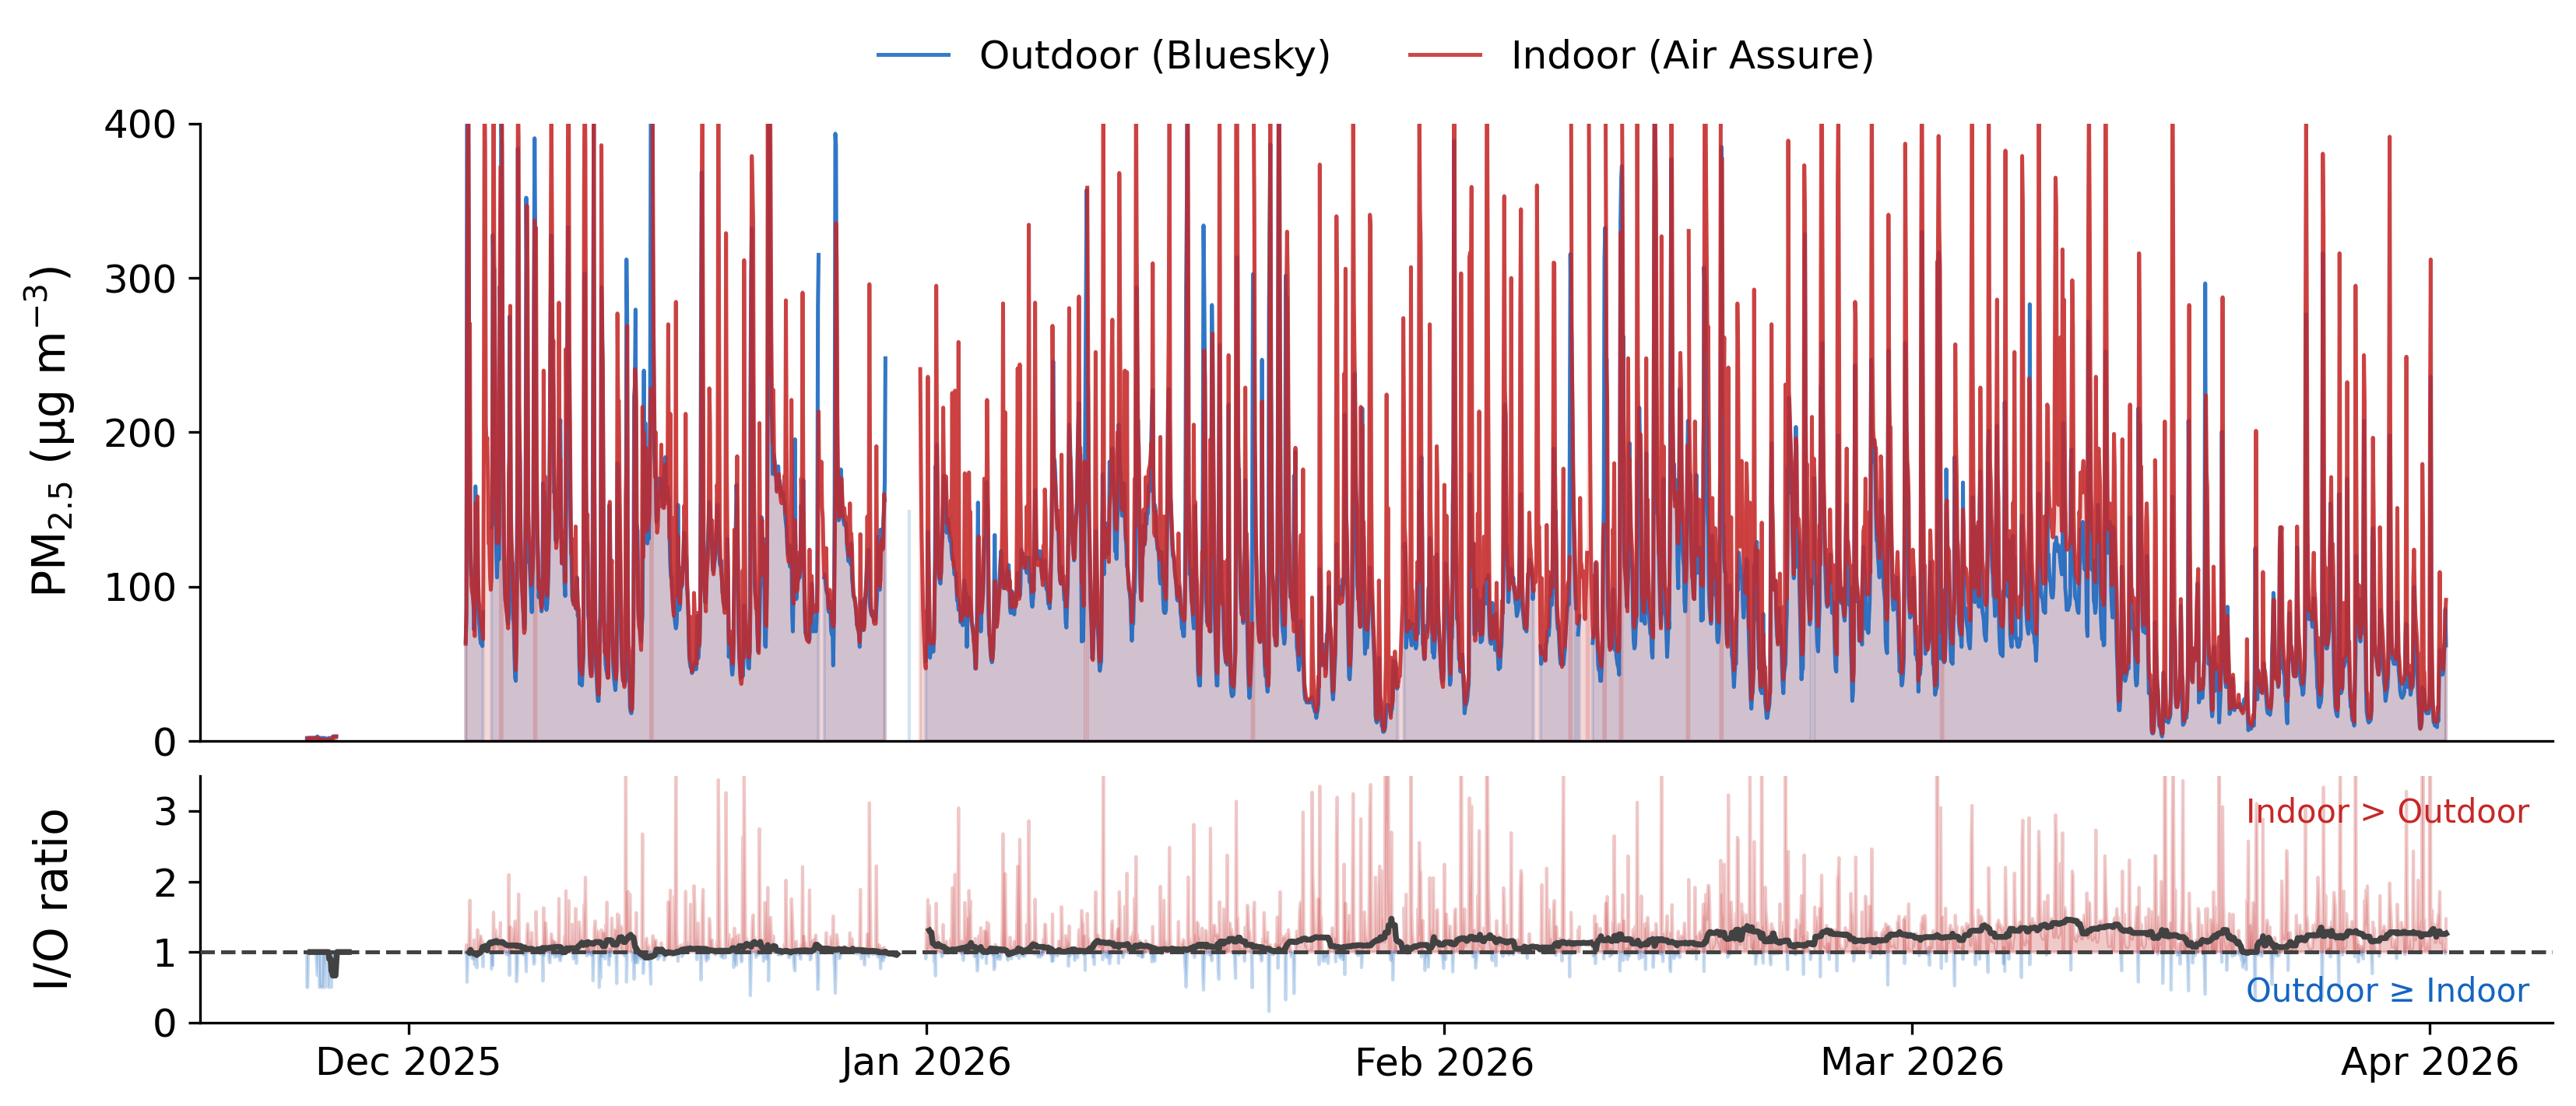

Saved → /Users/yubraj/Code/air-quality-research/figures/fig2_indoor_outdoor_timeseries.png
Caption check — Median I/O: 1.13  |  Indoor > Outdoor: 67.2% of hours


In [22]:

# ── Figure 2 ── Indoor vs Outdoor PM2.5 time series + I/O ratio ─────────────

POSTER_RC = {
    'font.family': 'sans-serif',
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 1.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 300,
}

P_OUT = '#1565C0'
P_IN  = '#C62828'
P_EQ  = '#424242'

with plt.rc_context(POSTER_RC):
    fig = plt.figure(figsize=(13, 5.0))
    gs  = fig.add_gridspec(2, 1, height_ratios=[3, 1.2], hspace=0.08)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    # ── Top panel ───────────────────────────────────────────────────────────
    pm_out = out_ov.set_index('ts')['pm25_clean'].resample('1h').median()
    pm_in  = in_ov.set_index('ts')['pm25_clean'].resample('1h').median()

    ax1.fill_between(pm_out.index, pm_out.values, alpha=0.18, color=P_OUT)
    ax1.fill_between(pm_in.index,  pm_in.values,  alpha=0.18, color=P_IN)
    l_out, = ax1.plot(pm_out.index, pm_out.values, lw=1.2, color=P_OUT, alpha=0.85, label='Outdoor (Bluesky)')
    l_in,  = ax1.plot(pm_in.index,  pm_in.values,  lw=1.2, color=P_IN,  alpha=0.85, label='Indoor (Air Assure)')

    ax1.set_ylabel('PM$_{2.5}$ (µg m$^{-3}$)', labelpad=8)
    ax1.set_ylim(0, 400)
    ax1.yaxis.set_major_locator(plt.MultipleLocator(100))
    ax1.legend(handles=[l_out, l_in], loc='lower center',
               bbox_to_anchor=(0.5, 1.02), ncol=2,
               frameon=False, handlelength=1.8, columnspacing=2.0)
    ax1.tick_params(bottom=False, labelbottom=False)

    # ── Bottom panel: I/O ratio ──────────────────────────────────────────────
    common  = pm_in.index.intersection(pm_out.index)
    io_raw  = (pm_in.loc[common] / pm_out.loc[common]).replace([np.inf, -np.inf], np.nan)
    io_roll = io_raw.rolling('24h', min_periods=6).median()

    ax2.axhline(1.0, color=P_EQ, lw=1.2, ls='--', zorder=3)
    ax2.fill_between(io_raw.index, io_raw.values, 1,
                     where=io_raw.fillna(0).values > 1,
                     alpha=0.25, color=P_IN, interpolate=True)
    ax2.fill_between(io_raw.index, io_raw.values, 1,
                     where=io_raw.fillna(2).values <= 1,
                     alpha=0.25, color=P_OUT, interpolate=True)
    ax2.plot(io_roll.index, io_roll.values, lw=1.8, color=P_EQ, zorder=4)

    ax2.set_ylabel('I/O ratio', labelpad=8)
    ax2.set_ylim(0, 3.5)
    ax2.yaxis.set_major_locator(plt.MultipleLocator(1))

    ax2.text(0.99, 3.2, 'Indoor > Outdoor', transform=ax2.get_yaxis_transform(),
             color=P_IN, fontsize=10, ha='right', va='top')
    ax2.text(0.99, 0.2, 'Outdoor ≥ Indoor', transform=ax2.get_yaxis_transform(),
             color=P_OUT, fontsize=10, ha='right', va='bottom')

    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax2.get_xticklabels(), rotation=0, ha='center')

    for spine in ['top', 'right']:
        ax1.spines[spine].set_visible(False)
        ax2.spines[spine].set_visible(False)

    fig.align_ylabels([ax1, ax2])

    out_path = Path('/Users/yubraj/Code/air-quality-research/figures/fig2_indoor_outdoor_timeseries.png')
    fig.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {out_path}')

    med_io = io_raw.median()
    pct_in_worse = (io_raw > 1).mean() * 100
    print(f'Caption check — Median I/O: {med_io:.2f}  |  Indoor > Outdoor: {pct_in_worse:.1f}% of hours')

**Figure 2.** Indoor PM₂.₅ frequently exceeded outdoor PM₂.₅ during the 128-day overlap window. The median indoor/outdoor ratio was 1.13, and indoor PM₂.₅ was higher than outdoor PM₂.₅ in 67.2% of matched hours. Top panel shows hourly median concentrations; bottom panel shows the hourly indoor/outdoor (I/O) ratio with a 24-hour rolling median (dark line). Dashed line marks I/O = 1 (equal indoor and outdoor). Location: Belauri, Nepal (28.68°N, 80.36°E). Period: November 2025 – April 2026.

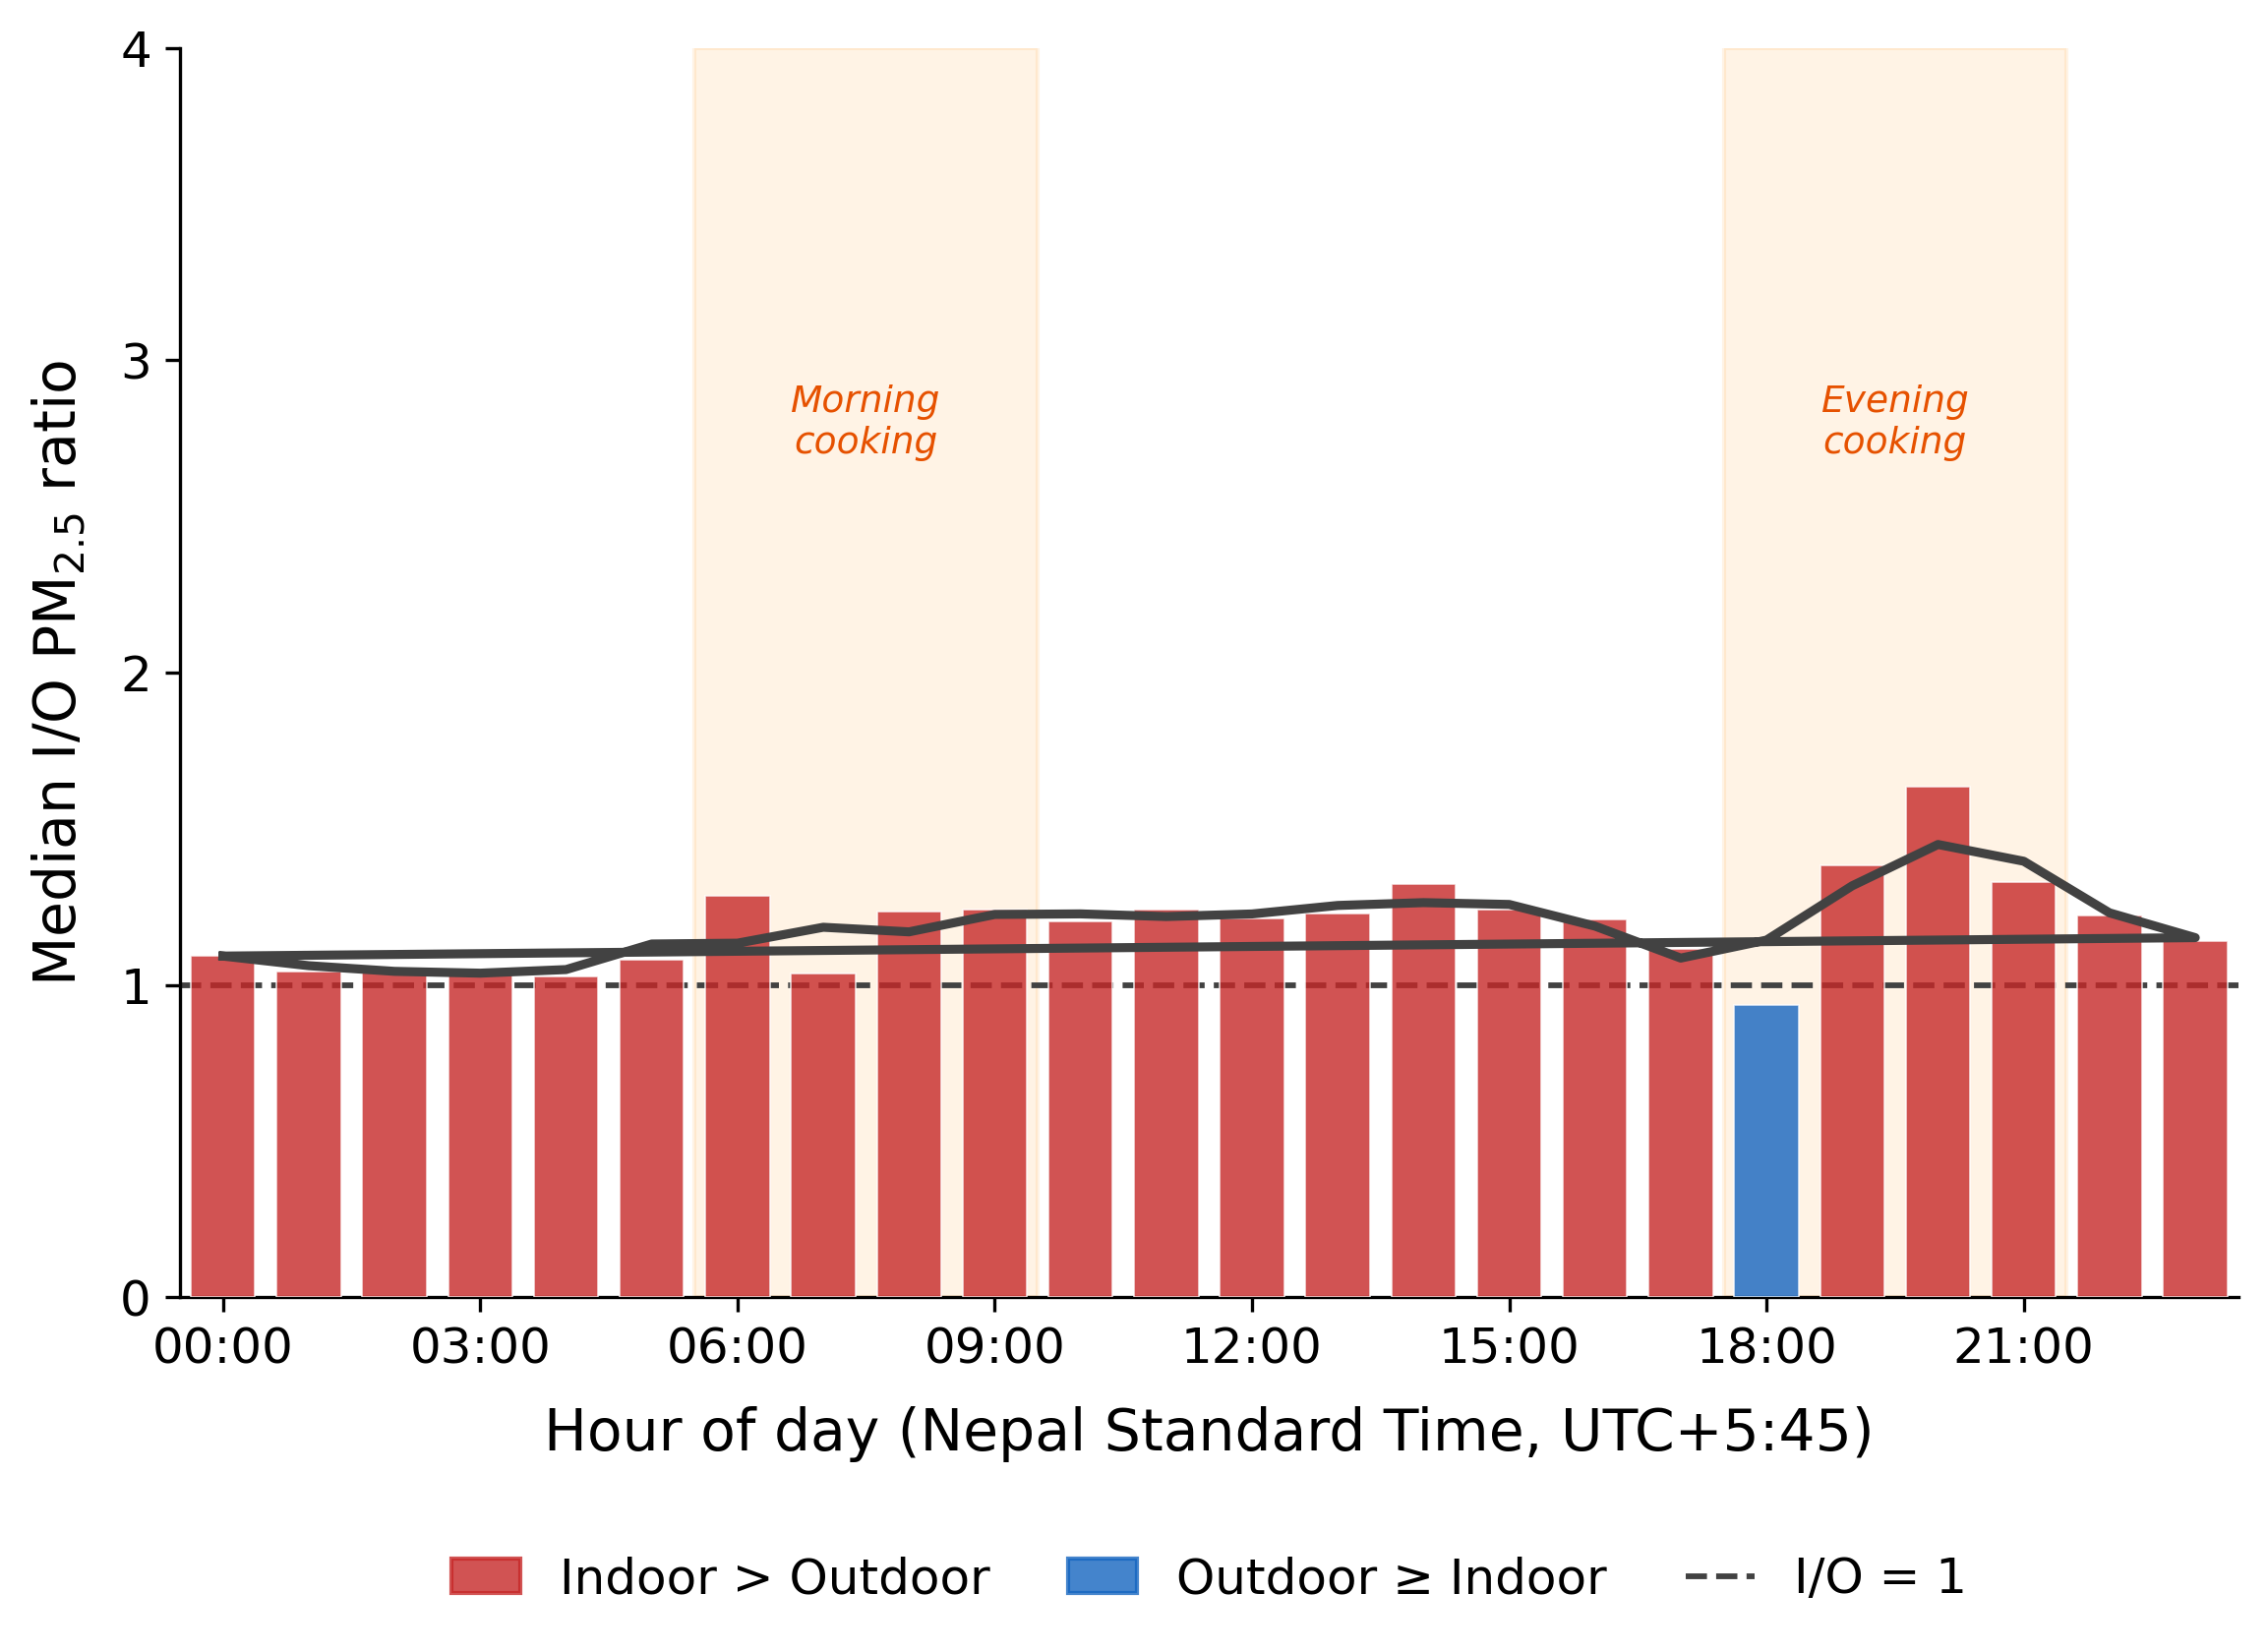

Saved → /Users/yubraj/Code/air-quality-research/figures/fig3_io_ratio_by_nst_hour.png
Peak I/O at 20:00 NST: 1.64
Trough I/O at 18:00 NST: 0.93


In [23]:

# ── Figure 3 ── Indoor/Outdoor ratio by local hour (Nepal Standard Time) ─────

NST_OFFSET = pd.Timedelta(hours=5, minutes=45)

def add_nst_hour(df):
    d = df.copy()
    d['ts_nst']   = d['ts'] + NST_OFFSET
    d['hour_nst'] = d['ts_nst'].dt.hour
    return d

out_nst = add_nst_hour(out_ov)
in_nst  = add_nst_hour(in_ov)

out_med_nst = out_nst.groupby('hour_nst')['pm25_clean'].median()
in_med_nst  = in_nst.groupby('hour_nst')['pm25_clean'].median()

common_h = out_med_nst.index.intersection(in_med_nst.index)
io_nst   = (in_med_nst.loc[common_h] / out_med_nst.loc[common_h]).replace([np.inf, -np.inf], np.nan)

with plt.rc_context(POSTER_RC):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    hours = io_nst.index.values

    # Cooking-period shading — muted amber, low alpha
    SHADE_KW = dict(alpha=0.10, color='#FF8F00', zorder=0)
    ax.axvspan(5.5,  9.5,  **SHADE_KW)
    ax.axvspan(17.5, 21.5, **SHADE_KW)

    # Cooking annotations at mid-height of the empty headroom (y ≈ 2.8)
    # so they sit comfortably above the bars (~1.6 max) and below the top
    ax.text(7.5,  2.8, 'Morning\ncooking', ha='center', va='center', fontsize=9,
            color='#E65100', style='italic')
    ax.text(19.5, 2.8, 'Evening\ncooking', ha='center', va='center', fontsize=9,
            color='#E65100', style='italic')

    # I/O = 1 reference
    ax.axhline(1.0, color=P_EQ, lw=1.4, ls='--', zorder=2)

    # Coloured bars
    bar_colors = [P_IN if v > 1 else P_OUT for v in io_nst.values]
    ax.bar(hours, io_nst.values, color=bar_colors, alpha=0.80, width=0.75,
           zorder=3, edgecolor='white', linewidth=0.4)

    # Smoothed trend line
    from scipy.ndimage import uniform_filter1d
    smooth = uniform_filter1d(io_nst.values, size=3, mode='wrap')
    ax.plot(np.append(hours, hours[0]),
            np.append(smooth, smooth[0]),
            color=P_EQ, lw=2.2, zorder=4, clip_on=False)

    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(0, 4.0)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)])
    ax.set_xlabel('Hour of day (Nepal Standard Time, UTC+5:45)', labelpad=8)
    ax.set_ylabel('Median I/O PM$_{2.5}$ ratio', labelpad=8)
    ax.yaxis.set_major_locator(plt.MultipleLocator(1))

    # Legend at lower left — bars peak at ~1.6, so y=0–0.8 range is data-free
    patch_in  = mpatches.Patch(color=P_IN,  alpha=0.80, label='Indoor > Outdoor')
    patch_out = mpatches.Patch(color=P_OUT, alpha=0.80, label='Outdoor ≥ Indoor')
    line_ref  = plt.Line2D([0], [0], color=P_EQ, lw=1.4, ls='--', label='I/O = 1')
    ax.legend(handles=[patch_in, patch_out, line_ref],
              loc='lower center', bbox_to_anchor=(0.5, -0.28),
              ncol=3, frameon=False, handlelength=1.4, columnspacing=1.6)

    out_path = Path('/Users/yubraj/Code/air-quality-research/figures/fig3_io_ratio_by_nst_hour.png')
    fig.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {out_path}')

    peak_h   = io_nst.idxmax()
    trough_h = io_nst.idxmin()
    print(f'Peak I/O at {peak_h:02d}:00 NST: {io_nst[peak_h]:.2f}')
    print(f'Trough I/O at {trough_h:02d}:00 NST: {io_nst[trough_h]:.2f}')

**Figure 3.** Indoor/outdoor PM₂.₅ ratios vary by time of day (Nepal Standard Time, UTC+5:45). Ratios above 1 (red bars) indicate periods when indoor PM₂.₅ exceeded outdoor PM₂.₅, suggesting that outdoor AQI alone may miss important indoor exposure patterns. Shaded regions mark typical morning (06:00–09:00 NST) and evening (18:00–21:00 NST) cooking periods. The dark line is a 3-hour smoothed trend. Each bar represents the median ratio across all days in the 128-day overlap window (24 November 2025 – 1 April 2026), Belauri, Nepal.

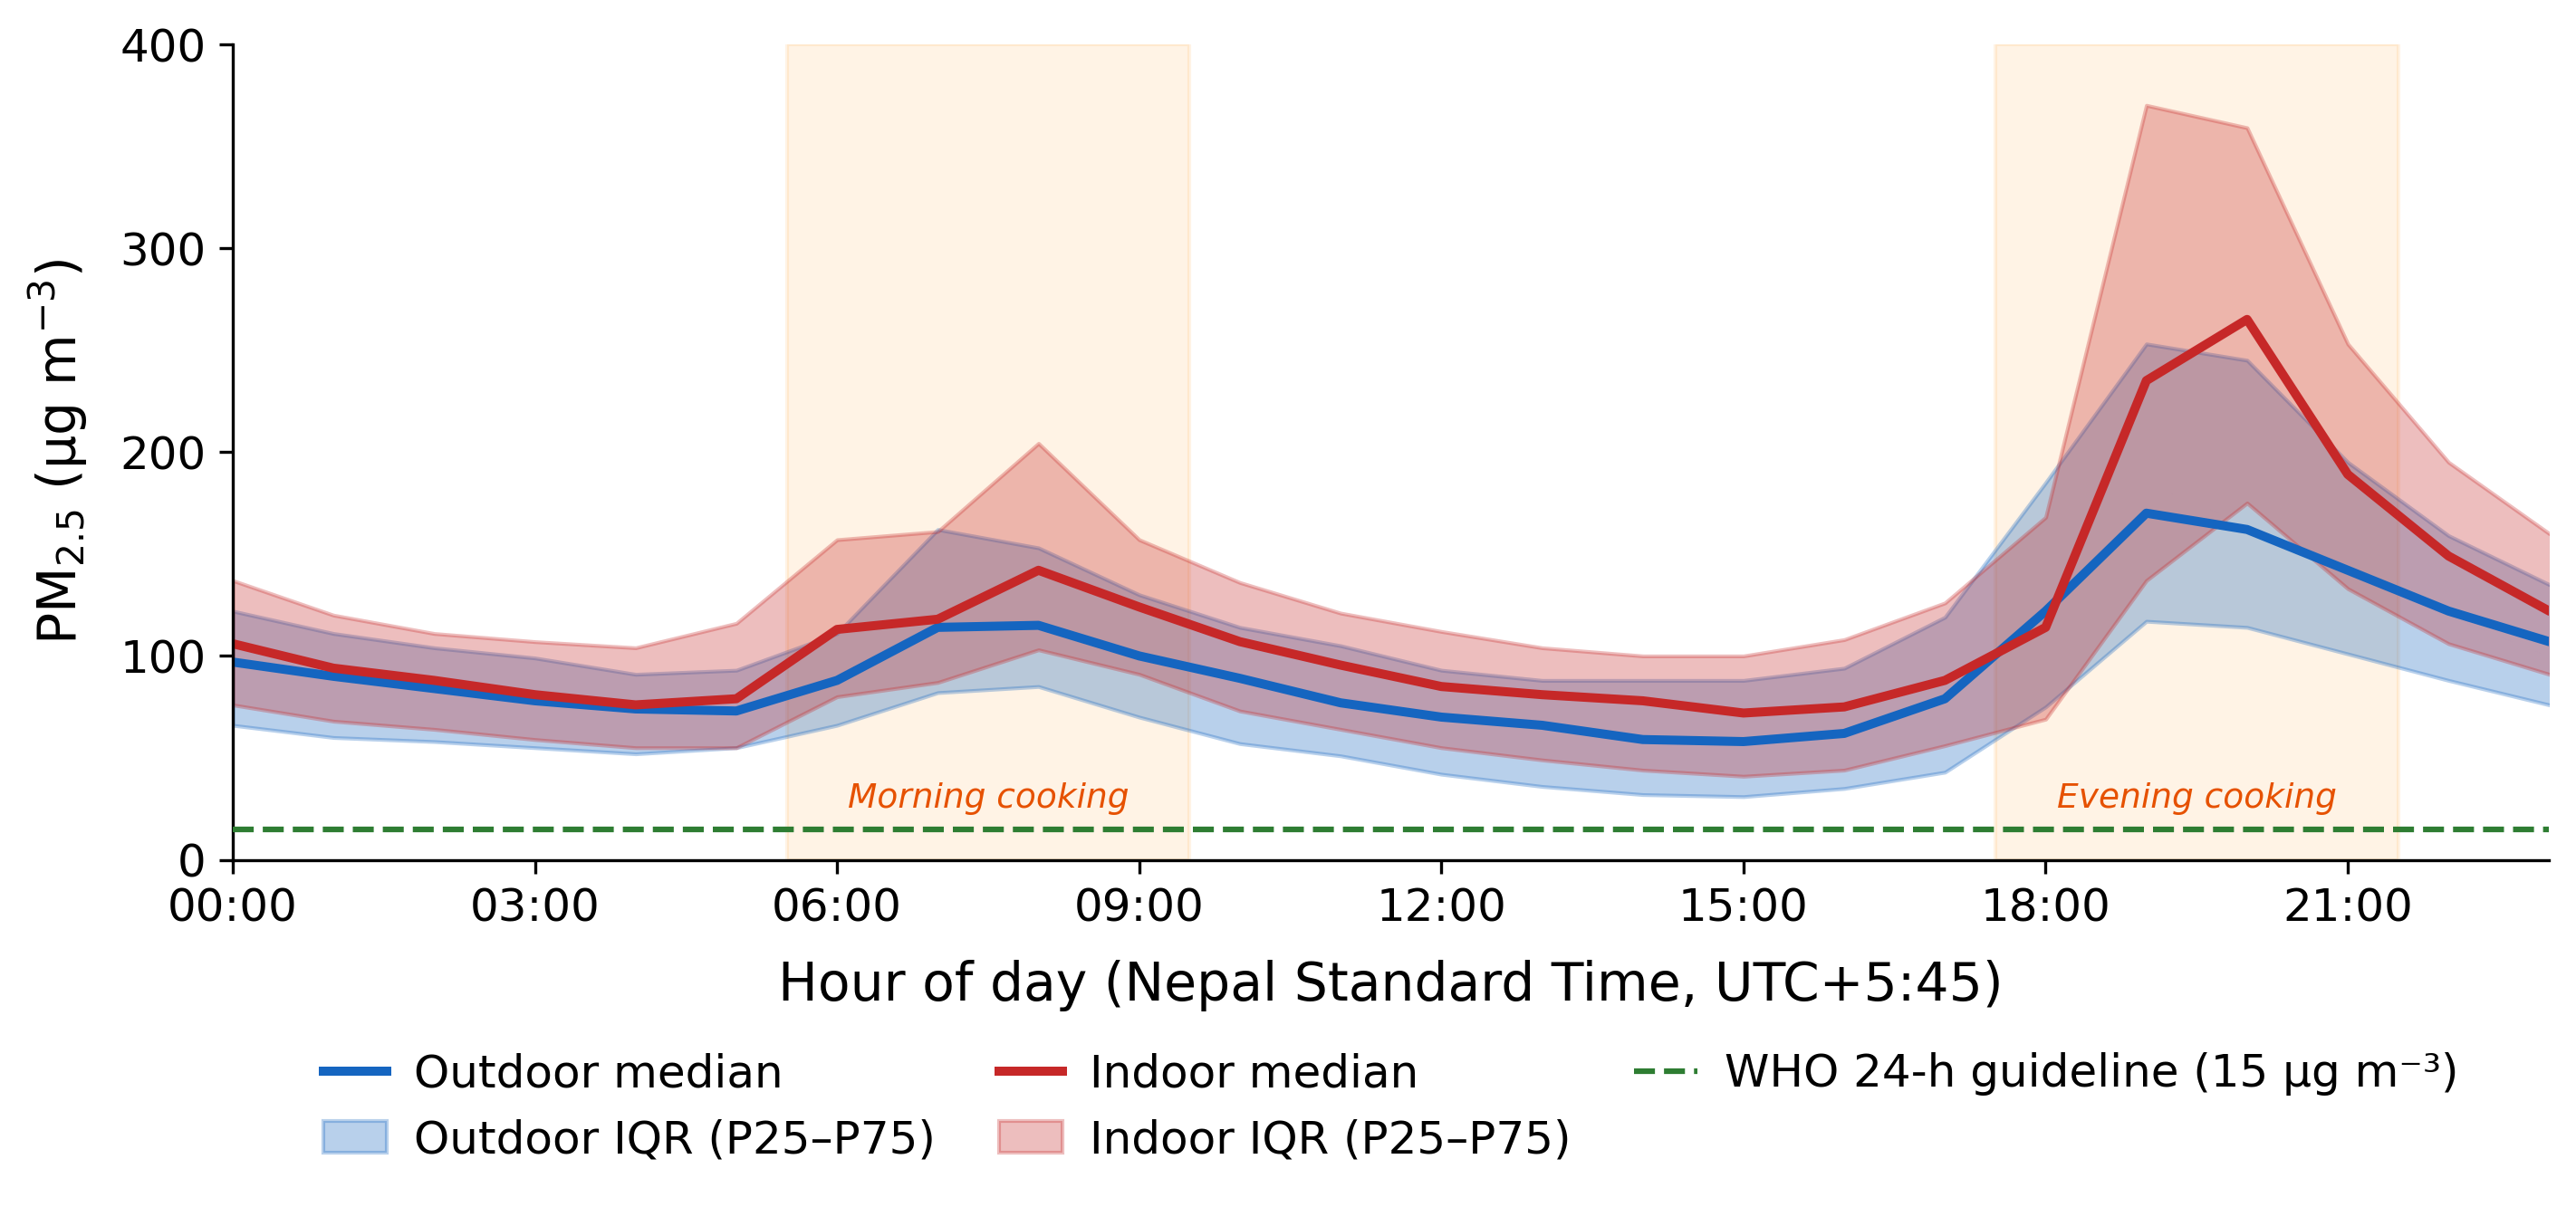

Saved → /Users/yubraj/Code/air-quality-research/figures/fig4_diurnal_ribbon.png


In [24]:

# ── Figure 4 ── Diurnal PM2.5 ribbon plot (NST hour) ────────────────────────

NST_OFFSET = pd.Timedelta(hours=5, minutes=45)

def with_nst_hour(df):
    d = df.copy()
    d['ts_nst']   = d['ts'] + NST_OFFSET
    d['hour_nst'] = d['ts_nst'].dt.hour
    return d

out_n = with_nst_hour(out_ov)
in_n  = with_nst_hour(in_ov)

def hourly_stats(df, col='pm25_clean'):
    g = df.groupby('hour_nst')[col]
    return pd.DataFrame({
        'p25': g.quantile(0.25),
        'med': g.median(),
        'p75': g.quantile(0.75),
    })

out_stats = hourly_stats(out_n)
in_stats  = hourly_stats(in_n)

hours = out_stats.index.values
h_ext = np.append(hours, 24)

def ext(s):
    return np.append(s.values, s.values[0])

WHO_24H = 15  # µg/m³

with plt.rc_context(POSTER_RC):
    fig, ax = plt.subplots(figsize=(11, 3.9))

    # Cooking-period shading
    ax.axvspan(5.5,  9.5,  alpha=0.10, color='#FF8F00', zorder=0)
    ax.axvspan(17.5, 21.5, alpha=0.10, color='#FF8F00', zorder=0)
    ax.text(7.5,  22, 'Morning cooking', ha='center', va='bottom',
            fontsize=9, color='#E65100', style='italic')
    ax.text(19.5, 22, 'Evening cooking', ha='center', va='bottom',
            fontsize=9, color='#E65100', style='italic')

    # WHO guideline
    ax.axhline(WHO_24H, color='#2E7D32', lw=1.5, ls='--', zorder=4,
               label=f'WHO 24-h guideline ({WHO_24H} µg m⁻³)')

    # Outdoor — IQR shading + median line
    ax.fill_between(h_ext, ext(out_stats['p25']), ext(out_stats['p75']),
                    alpha=0.30, color=P_OUT)
    ax.plot(h_ext, ext(out_stats['med']), lw=2.4, color=P_OUT, label='Outdoor median')

    # Indoor — IQR shading + median line
    ax.fill_between(h_ext, ext(in_stats['p25']), ext(in_stats['p75']),
                    alpha=0.30, color=P_IN)
    ax.plot(h_ext, ext(in_stats['med']), lw=2.4, color=P_IN, label='Indoor median')

    ax.set_xlim(0, 23)
    ax.set_ylim(0, 400)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)])
    ax.set_xlabel('Hour of day (Nepal Standard Time, UTC+5:45)', labelpad=8)
    ax.set_ylabel('PM$_{2.5}$ (µg m$^{-3}$)', labelpad=8)
    ax.yaxis.set_major_locator(plt.MultipleLocator(100))

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=P_OUT, lw=2.4, label='Outdoor median'),
        mpatches.Patch(color=P_OUT, alpha=0.30, label='Outdoor IQR (P25–P75)'),
        Line2D([0], [0], color=P_IN,  lw=2.4, label='Indoor median'),
        mpatches.Patch(color=P_IN,  alpha=0.30, label='Indoor IQR (P25–P75)'),
        Line2D([0], [0], color='#2E7D32', lw=1.5, ls='--',
               label=f'WHO 24-h guideline ({WHO_24H} µg m⁻³)'),
    ]
    ax.legend(handles=legend_elements,
              loc='lower center', bbox_to_anchor=(0.5, -0.42),
              ncol=3, frameon=False, handlelength=1.4,
              columnspacing=1.4, handletextpad=0.6)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    out_path = Path('/Users/yubraj/Code/air-quality-research/figures/fig4_diurnal_ribbon.png')
    fig.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {out_path}')

**Figure 4.** Diurnal PM₂.₅ concentration profiles for indoor (red) and outdoor (blue) sensors, Belauri, Nepal (24 Nov 2025 – 1 Apr 2026). Solid lines show the hourly median; shaded bands show the interquartile range (P25–P75). Hours are in Nepal Standard Time (UTC+5:45). Shaded regions mark typical morning and evening cooking periods. Both sensors record sustained exceedance of the WHO annual PM₂.₅ guideline (15 µg m⁻³) at all hours.

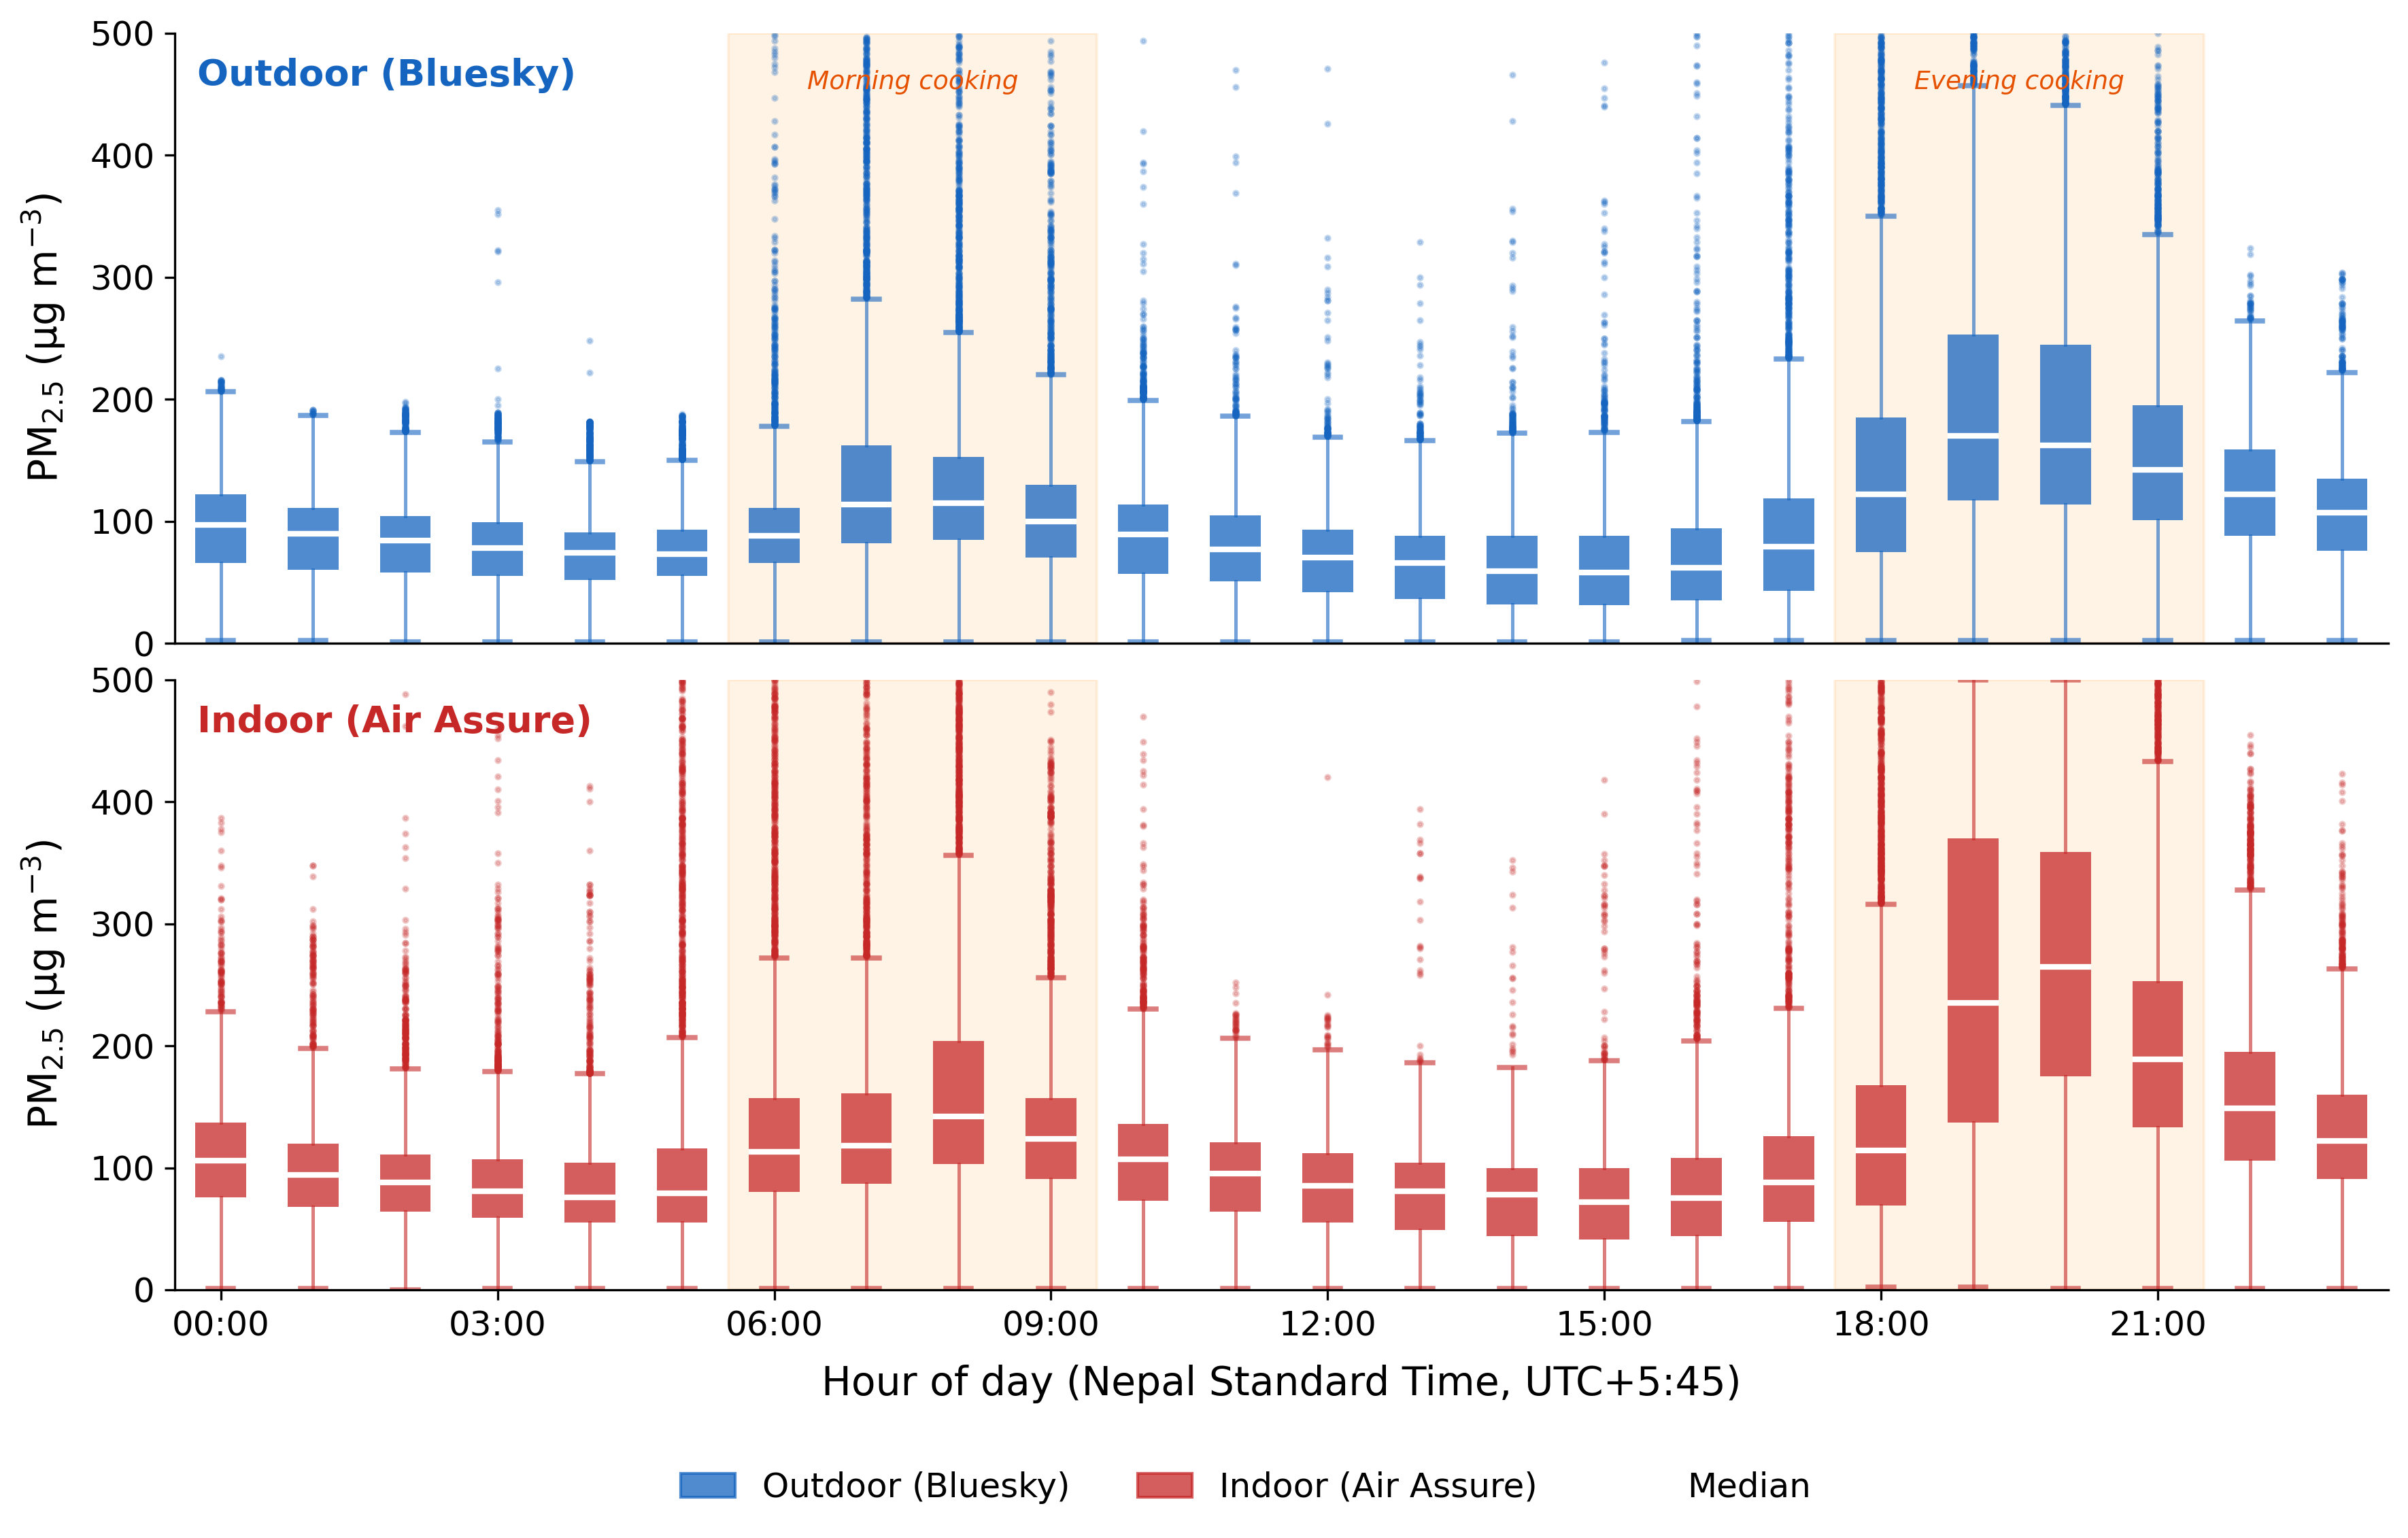

Saved → /Users/yubraj/Code/air-quality-research/figures/fig5_diurnal_boxplot.png


In [25]:

# ── Figure 5 ── Diurnal PM2.5 box-and-whisker plot (NST hour) ────────────────
# Two stacked panels share x-axis — one per sensor — so each set of 24 boxes
# has room to breathe and the colours remain unambiguous.

with plt.rc_context(POSTER_RC):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                              gridspec_kw={'hspace': 0.06})

    BP_KW = dict(
        widths=0.55,
        patch_artist=True,
        medianprops=dict(color='white', lw=2.0),
        whiskerprops=dict(lw=1.2),
        capprops=dict(lw=1.8),
        flierprops=dict(marker='o', markersize=1.5, alpha=0.25, lw=0),
        boxprops=dict(lw=0),
    )

    for ax, df, color, label in [
        (axes[0], out_n, P_OUT, 'Outdoor (Bluesky)'),
        (axes[1], in_n,  P_IN,  'Indoor (Air Assure)'),
    ]:
        # Build list of arrays, one per NST hour
        data_by_hour = [
            df.loc[df['hour_nst'] == h, 'pm25_clean'].dropna().values
            for h in range(24)
        ]

        bp = ax.boxplot(data_by_hour, positions=range(24), **BP_KW)

        # Fill boxes with sensor colour
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.75)

        # Whiskers and caps in the same colour, dimmer
        for line in bp['whiskers'] + bp['caps']:
            line.set_color(color)
            line.set_alpha(0.6)

        # Fliers
        for flier in bp['fliers']:
            flier.set_markerfacecolor(color)
            flier.set_markeredgecolor(color)

        # Cooking-period shading
        ax.axvspan(5.5,  9.5,  alpha=0.10, color='#FF8F00', zorder=0)
        ax.axvspan(17.5, 21.5, alpha=0.10, color='#FF8F00', zorder=0)

        ax.set_ylim(0, 500)
        ax.yaxis.set_major_locator(plt.MultipleLocator(100))
        ax.set_ylabel('PM$_{2.5}$ (µg m$^{-3}$)', labelpad=8)

        # Sensor label as in-plot text (top-left, away from data)
        ax.text(0.01, 0.96, label, transform=ax.transAxes,
                color=color, fontsize=13, fontweight='bold',
                va='top', ha='left')

        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    # Cooking annotations on top panel only (bottom panel x-axis labels carry hours)
    axes[0].text(7.5,  470, 'Morning cooking', ha='center', va='top',
                 fontsize=9, color='#E65100', style='italic')
    axes[0].text(19.5, 470, 'Evening cooking', ha='center', va='top',
                 fontsize=9, color='#E65100', style='italic')

    # Shared x-axis
    axes[1].set_xticks(range(0, 24, 3))
    axes[1].set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)])
    axes[1].set_xlabel('Hour of day (Nepal Standard Time, UTC+5:45)', labelpad=8)
    axes[1].tick_params(axis='x', which='both', bottom=True)
    axes[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # Shared legend below both panels
    from matplotlib.lines import Line2D
    legend_elements = [
        mpatches.Patch(color=P_OUT, alpha=0.75, label='Outdoor (Bluesky)'),
        mpatches.Patch(color=P_IN,  alpha=0.75, label='Indoor (Air Assure)'),
        Line2D([0], [0], color='white', lw=2, label='Median',
               markerfacecolor='grey', marker='_', markersize=10),
    ]
    fig.legend(handles=legend_elements,
               loc='lower center', bbox_to_anchor=(0.5, -0.04),
               ncol=3, frameon=False, handlelength=1.6, columnspacing=2.0)

    fig.align_ylabels(axes)

    out_path = Path('/Users/yubraj/Code/air-quality-research/figures/fig5_diurnal_boxplot.png')
    fig.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {out_path}')

**Figure 5.** Box-and-whisker plots of PM₂.₅ by hour of day (Nepal Standard Time) for outdoor (top, blue) and indoor (bottom, red) sensors at Belauri, Nepal (24 Nov 2025 – 1 Apr 2026). Each box spans the interquartile range (P25–P75); the white horizontal line shows the median; whiskers extend to 1.5× IQR; dots show outliers. Shaded regions mark typical morning and evening cooking periods. Indoor concentrations show consistently higher median and greater spread than outdoor across all hours.

Paired (date, hour) observations: 2,772  |  avg per hour: 116

Median difference (Indoor − Outdoor) by NST hour:
       med  ci_lo  ci_hi    sig
hour                           
0      5.0    NaN    NaN  False
1      3.0    NaN    NaN  False
2      1.5    NaN    NaN  False
3      1.0    NaN    NaN  False
4      0.0    NaN    NaN  False
5      1.0    NaN    NaN  False
6     19.0   10.5   27.0   True
7      0.0    NaN    NaN  False
8     19.5   15.0   30.5   True
9     17.0   15.0   20.5   True
10    14.0   10.5   18.0   True
11    12.0    NaN    NaN  False
12    12.5    NaN    NaN  False
13    10.5    8.8   12.6   True
14     9.0    NaN    NaN  False
15     8.0    NaN    NaN  False
16     7.0    NaN    NaN  False
17     6.0    NaN    NaN  False
18    -4.0    NaN    NaN  False
19    70.5   36.5  119.0   True
20    92.0   72.5  121.0   True
21    30.5    NaN    NaN  False
22    16.0    NaN    NaN  False
23     8.0    NaN    NaN  False


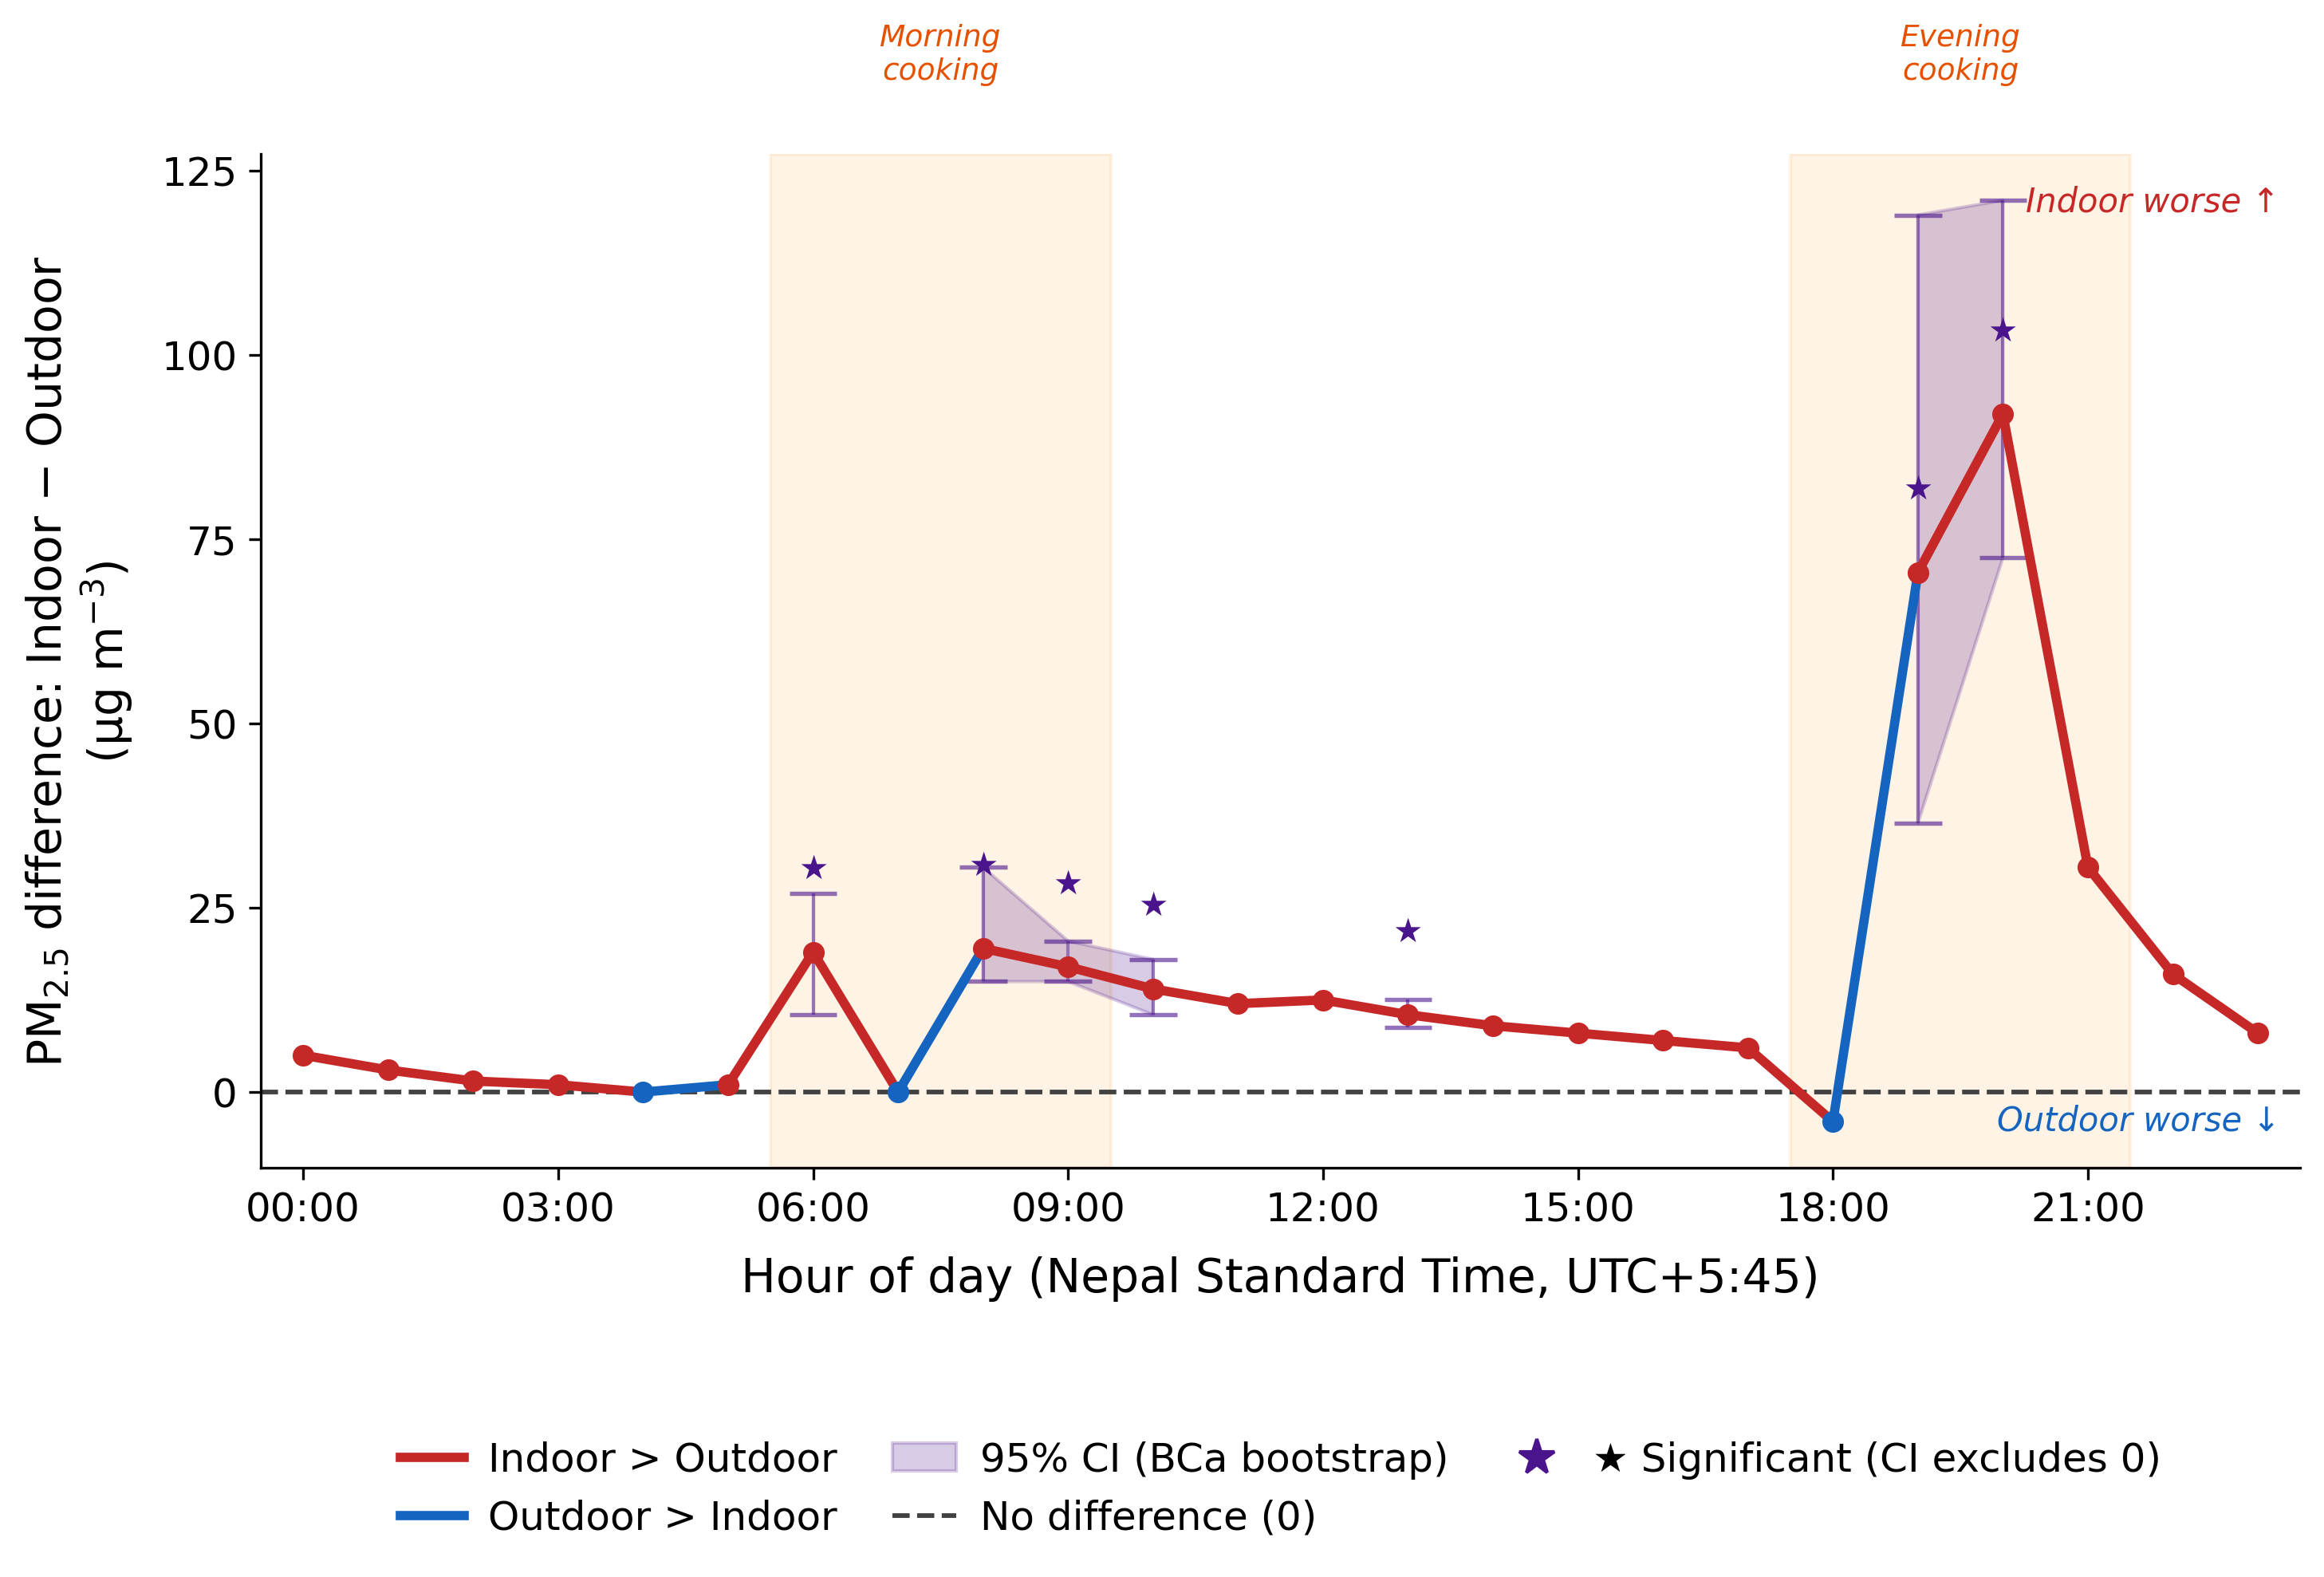


Saved → /Users/yubraj/Code/air-quality-research/figures/fig6_diff_by_hour_ci.png
Hours with statistically significant difference: 7/24


In [26]:

# ── Figure 6 ── Indoor − Outdoor PM2.5 difference by NST hour (bootstrapped CI)
#
# Strategy: for each (calendar date, NST hour) pair compute one median value
# per sensor → ~128 independent day-level differences per hour → bootstrap
# 95% CI on the median difference.  This removes within-hour autocorrelation
# and gives honest uncertainty bounds.

from scipy.stats import bootstrap as scipy_bootstrap

NST_OFFSET = pd.Timedelta(hours=5, minutes=45)

def daily_hourly_median(df, col='pm25_clean'):
    d = df.copy()
    d['ts_nst']   = d['ts'] + NST_OFFSET
    d['date_nst'] = d['ts_nst'].dt.date
    d['hour_nst'] = d['ts_nst'].dt.hour
    return (d.groupby(['date_nst', 'hour_nst'])[col]
              .median()
              .rename('pm25'))

out_dh = daily_hourly_median(out_ov).reset_index()
in_dh  = daily_hourly_median(in_ov).reset_index()

paired = pd.merge(out_dh, in_dh, on=['date_nst', 'hour_nst'], suffixes=('_out', '_in'))
paired['diff'] = paired['pm25_in'] - paired['pm25_out']

print(f"Paired (date, hour) observations: {len(paired):,}  |  avg per hour: {len(paired)/24:.0f}")

N_BOOT = 2000
np.random.seed(42)

results = []
for h in range(24):
    diffs = paired.loc[paired['hour_nst'] == h, 'diff'].dropna().values
    med = np.median(diffs)
    res = scipy_bootstrap(
        (diffs,), np.median,
        n_resamples=N_BOOT,
        confidence_level=0.95,
        method='BCa',
        random_state=42,
    )
    results.append({
        'hour':  h,
        'med':   med,
        'ci_lo': res.confidence_interval.low,
        'ci_hi': res.confidence_interval.high,
        'n':     len(diffs),
        'sig':   res.confidence_interval.low > 0 or res.confidence_interval.high < 0,
    })

res_df = pd.DataFrame(results).set_index('hour')
print("\nMedian difference (Indoor − Outdoor) by NST hour:")
print(res_df[['med','ci_lo','ci_hi','sig']].round(1).to_string())

# ── Plot ────────────────────────────────────────────────────────────────────
C_SIG = '#4A148C'   # deep purple for CI ribbon and significance markers

with plt.rc_context(POSTER_RC):
    fig, ax = plt.subplots(figsize=(11, 5.5))

    hours = res_df.index.values
    med   = res_df['med'].values
    ci_lo = res_df['ci_lo'].values
    ci_hi = res_df['ci_hi'].values
    sig   = res_df['sig'].fillna(False).values

    # Cooking-period shading
    ax.axvspan(5.5,  9.5,  alpha=0.10, color='#FF8F00', zorder=0)
    ax.axvspan(17.5, 21.5, alpha=0.10, color='#FF8F00', zorder=0)
    ax.text(7.5,  145, 'Morning\ncooking', ha='center', va='top',
            fontsize=9, color='#E65100', style='italic')
    ax.text(19.5, 145, 'Evening\ncooking', ha='center', va='top',
            fontsize=9, color='#E65100', style='italic')

    # Zero reference line
    ax.axhline(0, color=P_EQ, lw=1.4, ls='--', zorder=2)

    # CI ribbon
    ax.fill_between(hours, ci_lo, ci_hi,
                    alpha=0.22, color=C_SIG, zorder=3)

    # Error bar caps
    ax.vlines(hours, ci_lo, ci_hi, color=C_SIG, lw=1.0, alpha=0.45, zorder=3)
    ax.hlines(ci_lo, hours - 0.28, hours + 0.28, color=C_SIG, lw=1.3, alpha=0.6, zorder=3)
    ax.hlines(ci_hi, hours - 0.28, hours + 0.28, color=C_SIG, lw=1.3, alpha=0.6, zorder=3)

    # Median line — coloured segment by segment
    for i in range(len(hours) - 1):
        c = P_IN if med[i] > 0 else P_OUT
        ax.plot(hours[i:i+2], med[i:i+2], lw=2.8, color=c,
                solid_capstyle='round', zorder=4)
    for h, m in zip(hours, med):
        ax.plot(h, m, 'o', color=(P_IN if m > 0 else P_OUT), ms=5.5, zorder=5)

    # Significance markers — text-based stars (not marker style)
    for h, m, s in zip(hours, med, sig):
        if s:
            y_off = 9 if m >= 0 else -18
            ax.annotate('★', xy=(h, m), xytext=(h, m + y_off),
                        ha='center', va='bottom', fontsize=10,
                        color=C_SIG, zorder=6,
                        annotation_clip=False)

    ax.set_xlim(-0.5, 23.5)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)])
    ax.set_xlabel('Hour of day (Nepal Standard Time, UTC+5:45)', labelpad=8)
    ax.set_ylabel('PM$_{2.5}$ difference: Indoor − Outdoor\n(µg m$^{-3}$)', labelpad=8)
    ax.yaxis.set_major_locator(plt.MultipleLocator(25))

    ax.text(0.99, 0.97, 'Indoor worse ↑', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color=P_IN, style='italic')
    ax.text(0.99, 0.03, 'Outdoor worse ↓', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=10, color=P_OUT, style='italic')

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=P_IN,  lw=2.8, label='Indoor > Outdoor'),
        Line2D([0], [0], color=P_OUT, lw=2.8, label='Outdoor > Indoor'),
        mpatches.Patch(color=C_SIG, alpha=0.22, label='95% CI (BCa bootstrap)'),
        Line2D([0], [0], color=P_EQ, lw=1.4, ls='--', label='No difference (0)'),
        Line2D([0], [0], marker='*', color=C_SIG, lw=0,
               markersize=11, label='★ Significant (CI excludes 0)'),
    ]
    ax.legend(handles=legend_elements,
              loc='lower center', bbox_to_anchor=(0.5, -0.40),
              ncol=3, frameon=False, handlelength=1.6,
              columnspacing=1.4, handletextpad=0.6)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    out_path = Path('/Users/yubraj/Code/air-quality-research/figures/fig6_diff_by_hour_ci.png')
    fig.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'\nSaved → {out_path}')
    print(f'Hours with statistically significant difference: {sig.sum()}/24')

**Figure 6.** Median hourly PM₂.₅ difference (Indoor − Outdoor) by time of day in Nepal Standard Time (UTC+5:45), Belauri (24 Nov 2025 – 1 Apr 2026). Each point is the median of ~128 paired daily differences (one median per sensor per calendar-date per hour); error bars and purple ribbon show 95% bias-corrected accelerated (BCa) bootstrap confidence intervals. Red segments indicate hours when indoor exceeded outdoor; blue when outdoor exceeded indoor. ★ marks hours where the CI entirely excludes zero (statistically significant difference). Shaded bands mark typical cooking periods.

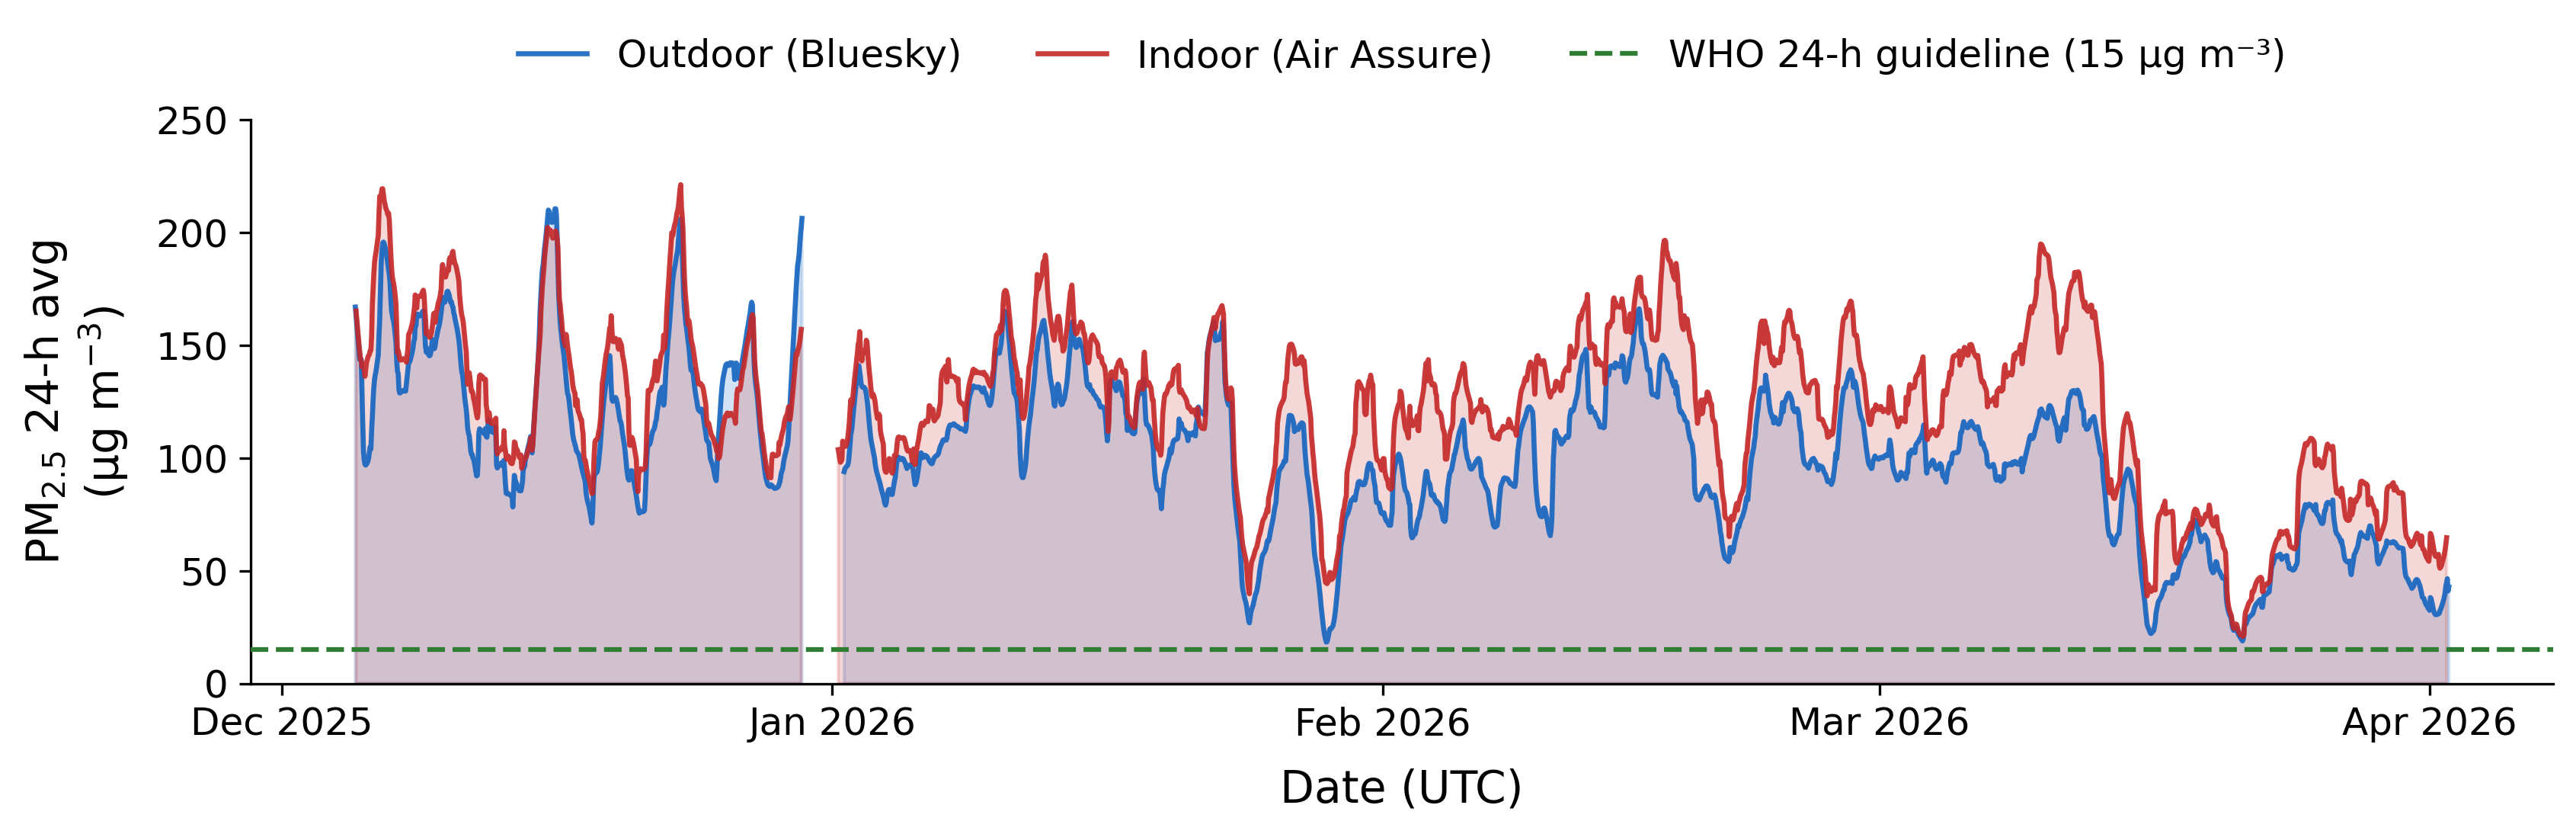

Saved → /Users/yubraj/Code/air-quality-research/figures/fig7_24h_rolling_avg.png
Remaining NaN hours in outdoor rolling avg: 73 (large outages kept as breaks)


In [27]:

# ── Figure 7 ── 24-hour rolling average PM2.5 — full continuous record ───────

WHO_24H   = 15
IN_START  = pd.Timestamp('2025-12-04 11:00:00', tz='UTC')
OUT_START = pd.Timestamp('2025-12-01 00:00:00', tz='UTC')

# Hourly medians
pm_out_h = (out_raw[out_raw['ts'] >= OUT_START]
            .set_index('ts')['pm25_clean']
            .resample('1h').median())

pm_in_h  = (in_raw[in_raw['ts'] >= IN_START]
            .set_index('ts')['pm25_clean']
            .resample('1h').median())

# Fill short sensor dropouts (≤ 12 h) before rolling to avoid artificial gap
# amplification. Outages > 12 h remain as NaN and show as honest breaks.
pm_out_h = pm_out_h.interpolate(method='time', limit=12)
pm_in_h  = pm_in_h.interpolate(method='time', limit=12)

# 24-h rolling mean
roll_out = pm_out_h.rolling(window=24, min_periods=18).mean()
roll_in  = pm_in_h.rolling(window=24, min_periods=18).mean()

from matplotlib.lines import Line2D

with plt.rc_context(POSTER_RC):
    fig, ax = plt.subplots(figsize=(13, 3.2))

    ax.fill_between(roll_out.index, roll_out.values, alpha=0.18, color=P_OUT)
    ax.fill_between(roll_in.index,  roll_in.values,  alpha=0.18, color=P_IN)

    l_out, = ax.plot(roll_out.index, roll_out.values,
                     lw=1.6, color=P_OUT, alpha=0.9, label='Outdoor (Bluesky)')
    l_in,  = ax.plot(roll_in.index,  roll_in.values,
                     lw=1.6, color=P_IN,  alpha=0.9, label='Indoor (Air Assure)')

    ax.axhline(WHO_24H, color='#2E7D32', lw=1.5, ls='--', zorder=4)

    ax.set_ylim(0, 250)
    ax.yaxis.set_major_locator(plt.MultipleLocator(50))
    ax.set_ylabel('PM$_{2.5}$ 24-h avg\n(µg m$^{-3}$)', labelpad=8)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
    ax.set_xlabel('Date (UTC)', labelpad=8)

    legend_elements = [
        l_out, l_in,
        Line2D([0], [0], color='#2E7D32', lw=1.5, ls='--',
               label=f'WHO 24-h guideline ({WHO_24H} µg m⁻³)'),
    ]
    ax.legend(handles=legend_elements,
              loc='lower center', bbox_to_anchor=(0.5, 1.02),
              ncol=3, frameon=False, handlelength=1.8, columnspacing=2.0)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    out_path = Path('/Users/yubraj/Code/air-quality-research/figures/fig7_24h_rolling_avg.png')
    fig.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {out_path}')

    remaining = roll_out.isna().sum()
    print(f'Remaining NaN hours in outdoor rolling avg: {remaining} (large outages kept as breaks)')

**Figure 7.** 24-hour rolling average PM₂.₅ for the outdoor (blue, Bluesky 81432434001, July 2025 – April 2026) and indoor (red, Air Assure 81442406076, from 4 December 2025) sensors at Belauri, Nepal. The indoor record excludes a disconnected 2-day fragment (24–25 November 2025) that preceded a 186-hour data gap. The WHO 24-hour mean PM₂.₅ guideline (15 µg m⁻³) is shown as a dashed green line; both sensors exceeded this level on virtually all days throughout the monitoring period.